In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT
from scipy.stats import norm
from scipy.optimize import curve_fit

In [29]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [3]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-14'

In [4]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_84TeV_haaexcl'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$',
               'color' : color_sequence[0]},
#    'ttyy' : { 'sample_list' : ['mgp8_pp_ttaa01j_5f_84TeV'], 
#               'label' : r'$ttH \rightarrow \gamma\gamma$',
#               'color' : color_sequence[1]},
}


selection = {
    'photons' : "$\geq 2$ photons"
}

process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json",
                 "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [5]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [6]:
def sigma_eta(energy) :
    return np.sqrt((1.36/np.sqrt(energy))**2 + 0.10**2) * 1e-3 
def sigma_phi(energy) :
    return np.sqrt((3.76/np.sqrt(energy))**2 + 0.22**2) * 1e-3 
def sigma_e(energy) :
    return np.sqrt(energy**2*0.0015**2 + energy*0.082**2 + 0.31**2)

In [7]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [8]:

from importlib import import_module
import sys
sys.path.insert(1, "../")

In [9]:
selection = {
#    "nocuts" : "All events",
    'photons' : "$\geq 2$ photons"
#    "lep_channel" : "Photon and $b$-jet sel., $\geq$ 1 lepton",
#    "pT_yy_bin1" : "0$\leq p_{T}(\gamma\gamma)$< 60 GeV",
#    "pT_yy_bin2" : "60$\leq p_{T}(\gamma\gamma)$< 120 GeV",
#    "pT_yy_bin3" : "120$\leq p_{T}(\gamma\gamma)$< 200 GeV",
#    "pT_yy_bin4" : "200$\leq p_{T}(\gamma\gamma)$< 300 GeV",
#    "pT_yy_bin5" : "$p_{T}(\gamma\gamma)\geq$ 300 GeV",
}
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList
variables_list = ['E_y1', 'pT_y1', 'eta_y1', 'phi_y1', 
                  'true_E_y1', 
                  'true_pT_y1', 'true_eta_y1', 'true_phi_y1',
                  'E_y2', 'pT_y2', 'eta_y2', 'phi_y2', 
                  'true_E_y2', 'true_pT_y2', 'true_eta_y2', 'true_phi_y2',
                  'pT_higgs',
                  'm_yy', 'true_m_yy',
                  'cos_theta_y_y',
                  'weight']

In [10]:
df = {}
sow = {}

In [11]:
for p in process.keys() :
    if p in list(df.keys()) :
        pass
    else :
        df[p] = {}
    print(p)
    for s in selection.keys() :
        if s in list(df[p].keys()) :
            pass
        else :
            print("\t\t"+s)
            df1 = []
            sow[p] = []
            for sample in process[p]['sample_list'] :
                inputfile = os.path.join(basedir, sample+"_"+s+".root")
                # get sum of weights
                f = ROOT.TFile.Open(inputfile)
                sow[p].append(f.Get("SumOfWeights").GetVal())
                f.Close()
                # get sample dict
                for d in process_dicts :
                    if sample in list(d.keys()) :
                        process_dict = d.copy()
                        break
                # get sample
                with uproot.open(inputfile) as f :
                    awk = f['events'].arrays(expressions=variables_list, library='ak')
                    df1.append(ak.to_dataframe(awk))
                    df1[-1]["weight"] = df1[-1]["weight"]/sow[p][-1]*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
            df[p][s] = pd.concat(df1, copy=True, ignore_index=True)

ttHyy
		photons


In [17]:
dfs = df['ttHyy']['photons'].copy()
#dfb = df['ttyy']['photons'].copy()

In [18]:
ENERGY_BINS = np.array([20,30,40,50,60,70,80,90,100,
              120,140,160,180,200,220,250,280,
               310,340,370,400,450,500,550,600,
              700,800,900,1000], dtype=np.float64)
x = 0.5*(ENERGY_BINS[1:] + ENERGY_BINS[:-1])
xerr = 0.5*(ENERGY_BINS[1:] - ENERGY_BINS[:-1])
yeta = np.zeros(len(ENERGY_BINS)-1)
yetaerr = np.zeros(len(ENERGY_BINS)-1)
yphi = np.zeros(len(ENERGY_BINS)-1)
yphierr = np.zeros(len(ENERGY_BINS)-1)

In [19]:
PHOTON_VARIABLES = ['E_y', 'pT_y', 'eta_y', 'phi_y', 'true_E_y', 'true_eta_y', 'true_phi_y']

In [20]:
dfs1 = dfs[['E_y1', 'pT_y1', 'eta_y1', 'phi_y1', 'true_E_y1', 'true_eta_y1', 'true_phi_y1']]
dfs2 = dfs[['E_y2', 'pT_y2', 'eta_y2', 'phi_y2', 'true_E_y2', 'true_eta_y2', 'true_phi_y2']]

In [21]:
dfs1 = dfs1.rename(columns={v+"1" : v for v in PHOTON_VARIABLES})
dfs2 = dfs2.rename(columns={v+"2" : v for v in PHOTON_VARIABLES})

In [22]:
dfss = pd.concat([dfs1,dfs2], copy=True, ignore_index=True)

In [23]:
dfss.head()

,E_y,pT_y,eta_y,phi_y,true_E_y,true_eta_y,true_phi_y
0,63.753525,63.418781,-0.102700,0.718261,63.532352,-0.102746,0.717834
1,314.335541,196.670303,1.045595,0.099479,314.611899,1.045578,0.099723
2,949.088562,137.192444,-2.622000,-2.953497,949.196927,-2.621866,-2.953953
3,301.613983,172.039642,-1.161012,-0.793820,304.521364,-1.161048,-0.793902
4,179.521484,173.788345,0.256162,1.219183,180.575472,0.256303,1.219264


In [24]:
dfss['energy_bin'] = np.digitize(dfss['E_y'], ENERGY_BINS)

In [25]:
def fit_func(x,a,mu,sigma):
    """gaussian function used for the fit"""
    return a * norm.pdf(x,loc=mu,scale=sigma)

In [26]:
def get_gaussian_fit(data, w=None):
    "get_gaussian_fit(data, w=None) --> returns parameters and errors"
    if len(data) == 0:
        return None
    data = sorted(data)
    min_value = data[max(0, int(len(data) * 0.01))]
    max_value = data[min(int(len(data) * 0.98) - 1, len(data) - 1)]
    nbins = int(max(20, len(data) / 100))
    data = np.array(data, dtype=np.float64)
    histo = ROOT.TH1F("histofit", "histofit", nbins, min_value, max_value)
    if w is not None:
        w = np.array(w, dtype=np.float64)
        histo.FillN(len(data), data, w)
    else:
        histo.FillN(len(data), data, np.ones(len(data)))
    center = histo.GetMean()
    sigma = histo.GetRMS()
    histo.Print()

    fitmin = sigma * (-3) + center
    fitmax = sigma * (+2) + center

    fitsf1 = ROOT.TF1("gaus", "gaus", fitmin, fitmax)

    for i in range(6):
        histo.Fit(fitsf1, "0Q", "", fitmin, fitmax)
        center = fitsf1.GetParameter(1)
        sigma = fitsf1.GetParameter(2)
        fitmin = sigma * (-1.) + center
        fitmax = sigma * (+2.5) + center

    if fitsf1 is None:
        return None
    return [fitsf1.GetParameter(i) for i in (0, 1, 2)], [fitsf1.GetParError(i) for i in (0, 1, 2)]

/tmp/elmazzeo/ipykernel_563226/3674823204.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


[#1] INFO:Fitting -- RooAbsPdf::fitTo(gaus_eta_over_gaus_eta_Int[eta]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using CPU computation library compiled with -mavx512
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_gaus_eta_over_gaus_eta_Int[eta]_) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
RooAbsMinimizerFcn: Minimized function has error status.
Returning maximum FCN so far (-330559) to force MIGRAD to back out of this region. Error log follows.
Parameter values: 	mu_eta=0	sigma_eta=1.37367e-05
RooAbsPdf::gaus_eta_over_gaus_eta_Int[eta][ numerator=gaus_eta denominator=gaus_eta_Int[eta] ]
     getLogVal() top-level p.d.f not greater than zero @ numerator=gaus_eta=1, denominator=gaus_eta_Int[eta]=3.44328e-05
     getLogVal() top-level p.d.f

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =      -332438.5729 Edm =         576757983 NCalls =      9
Info in <Minuit2>: NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : -355948.2505
  Edm           : 4.834449413
  Internal parameters:	[                0     -1.235807203]	
  Internal gradient  :	[      411.9892797      5717.444643]	
  Internal covariance matrix:
[[  2.9581999e-06              0]
 [              0  5.7620567e-07]]]
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : -355948.2505
  Edm           : 4.834449413
  Internal parameters:	[                0     -1.235807203]	
  Internal gradient  :	[      411.9892797      5717.444643]	
  Internal covariance matrix:
[[  2.9581999e-06              0]
 [              0  5.7620567e-07]]]
Info i

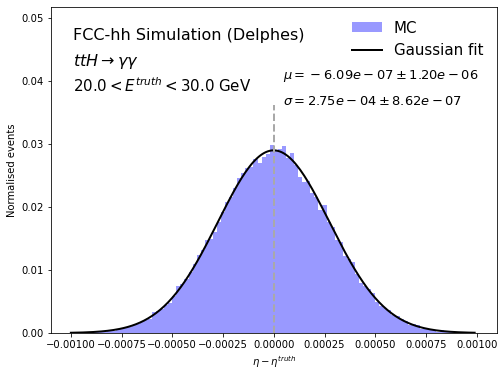

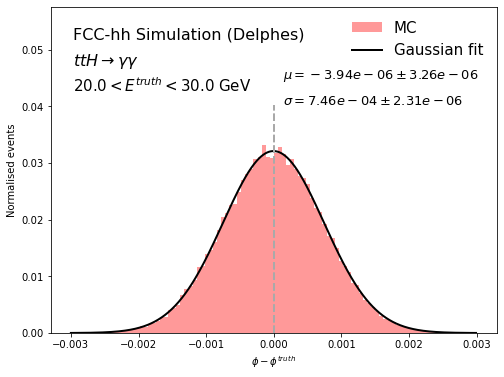

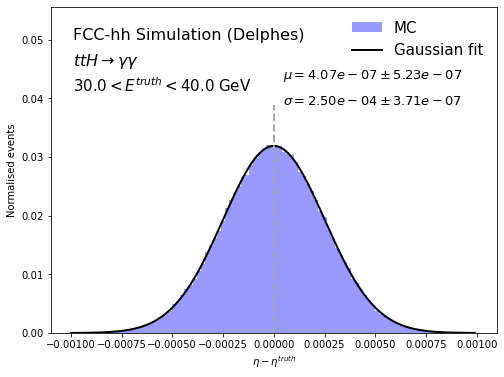

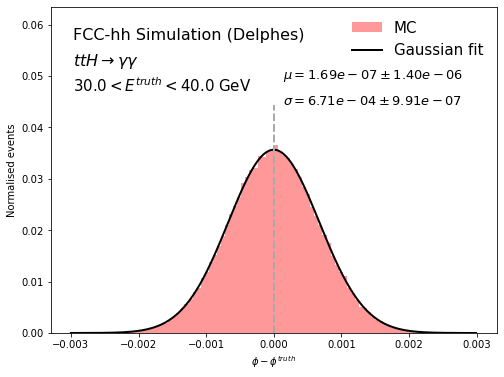

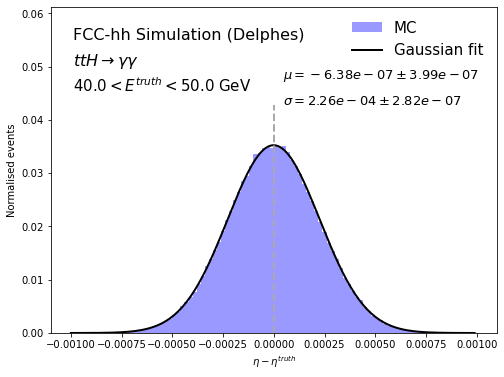

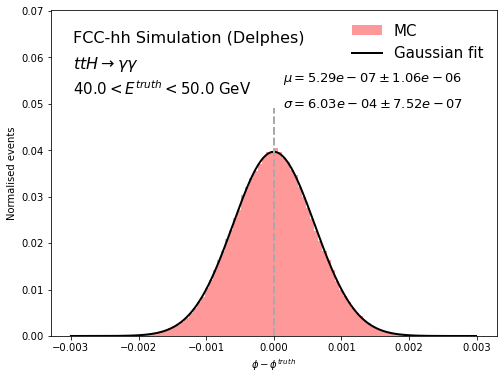

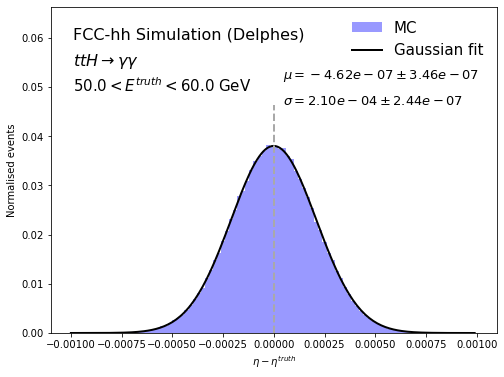

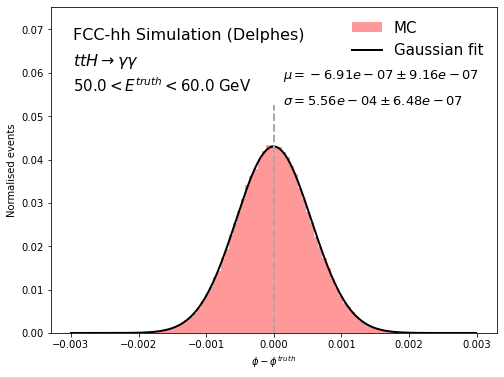

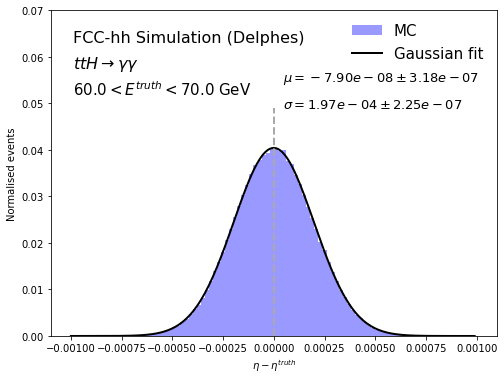

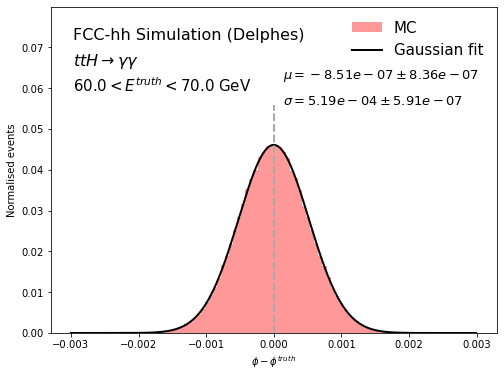

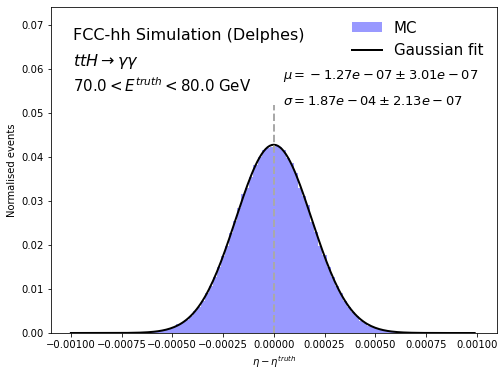

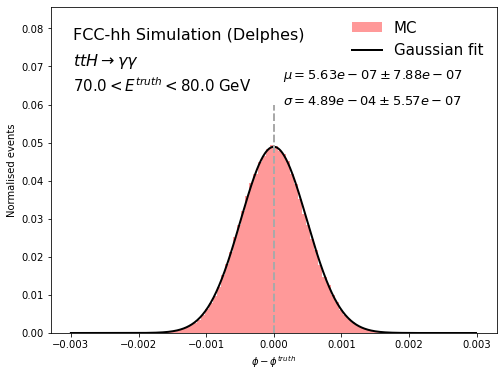

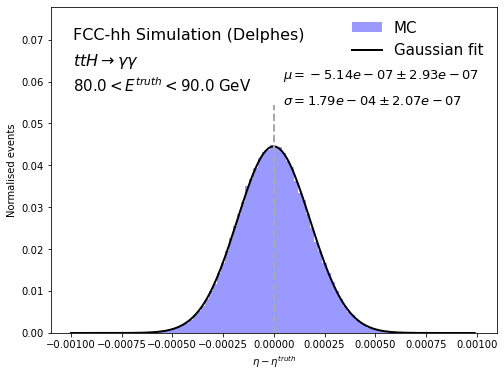

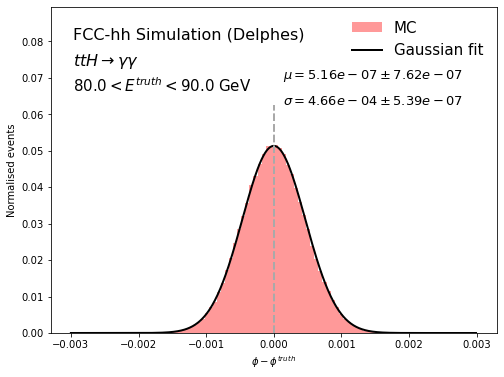

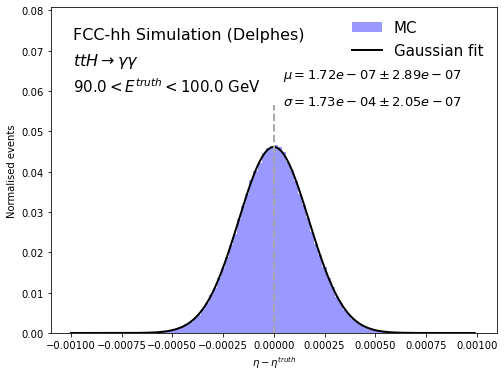

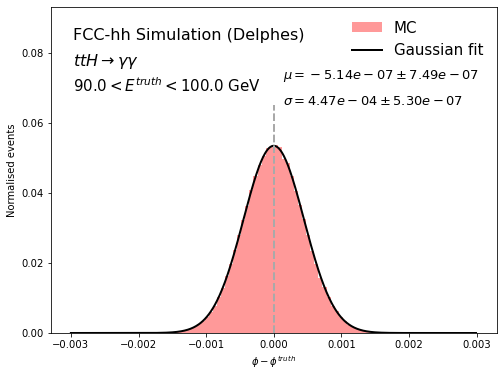

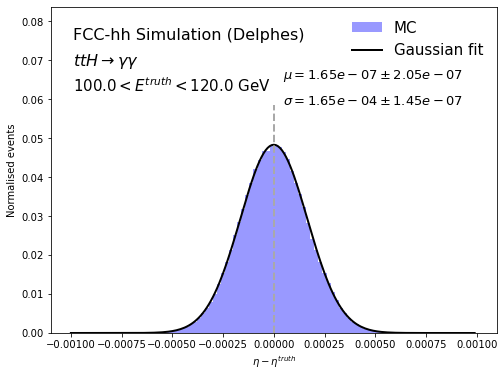

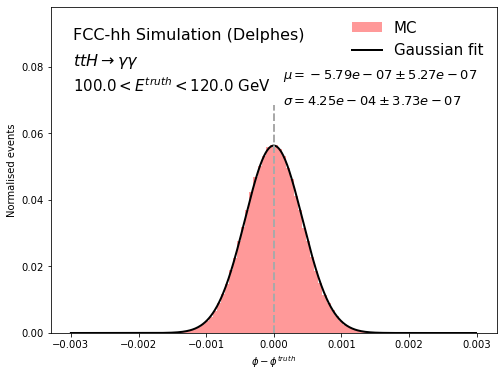

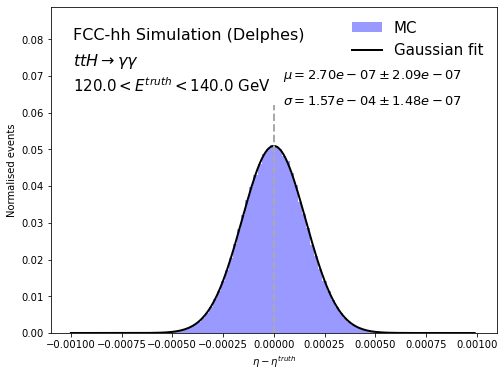

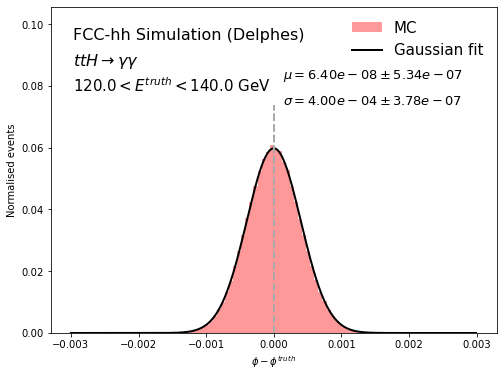

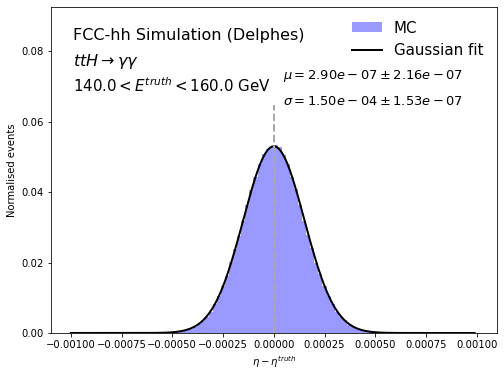

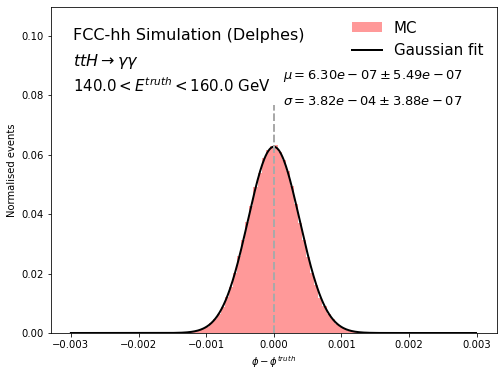

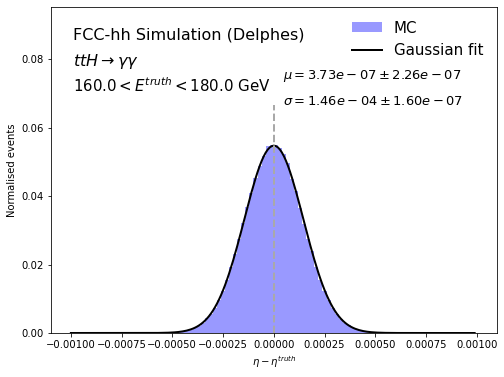

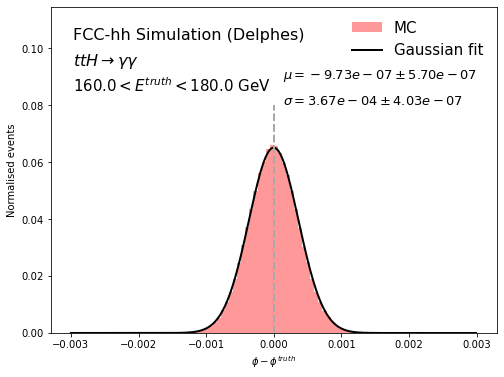

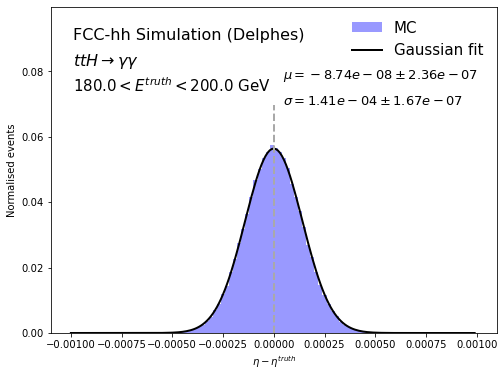

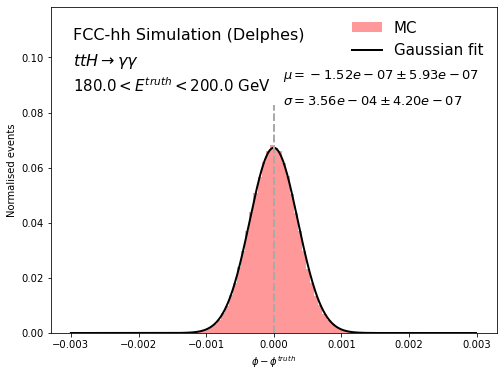

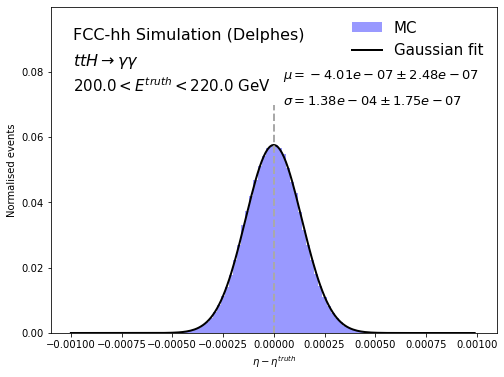

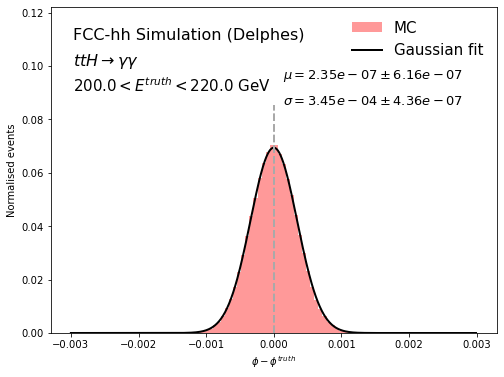

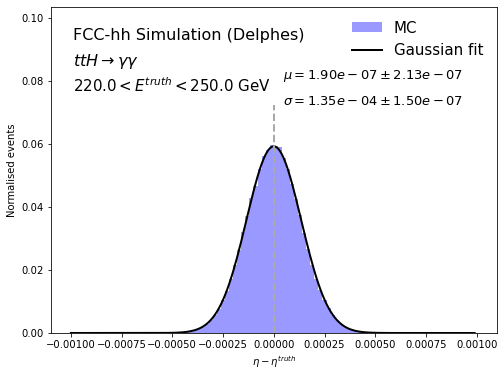

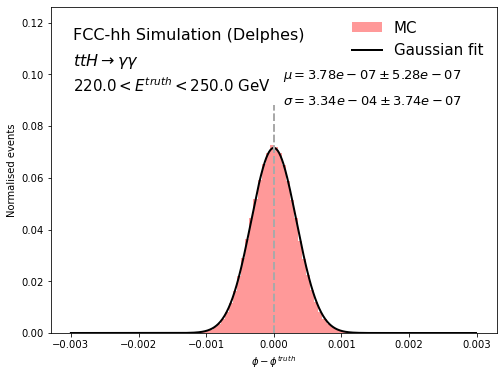

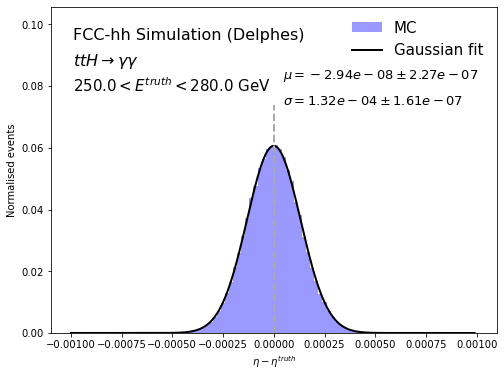

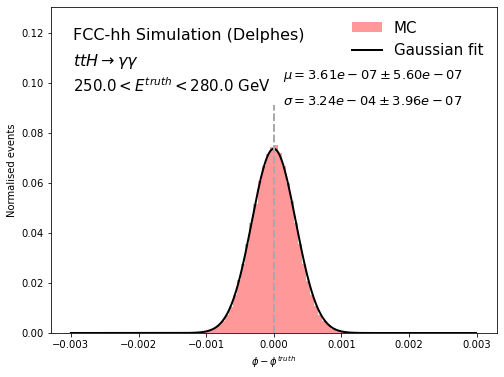

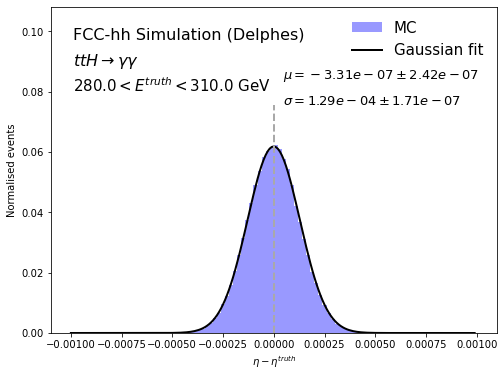

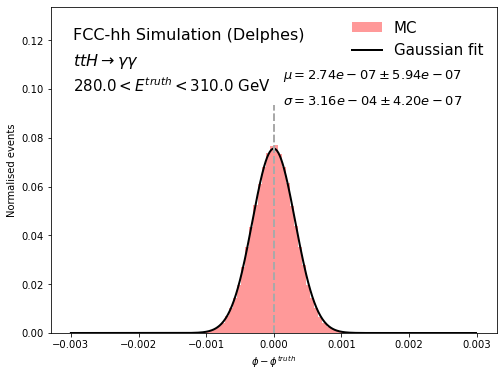

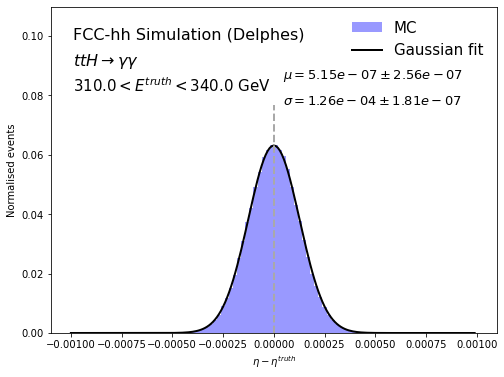

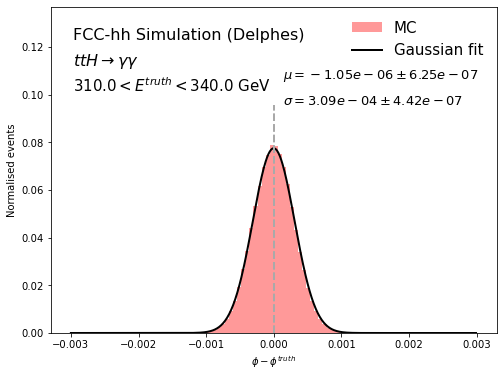

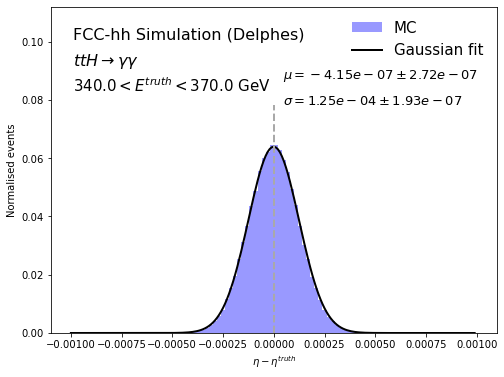

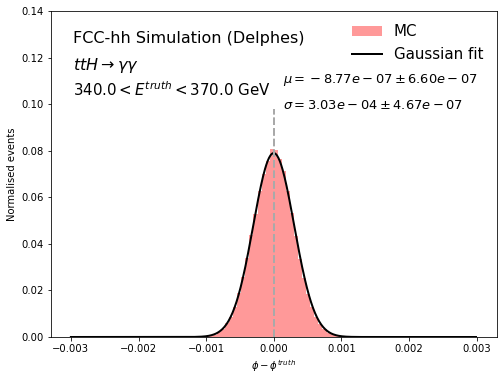

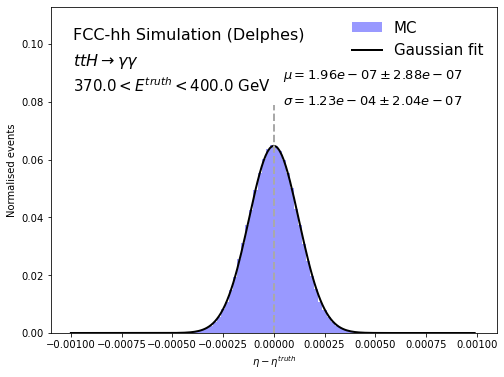

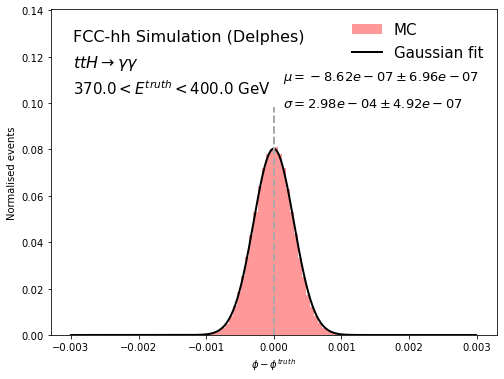

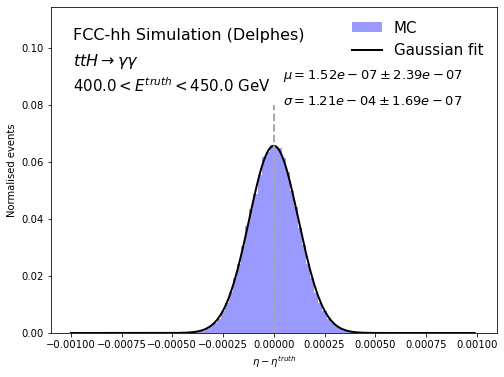

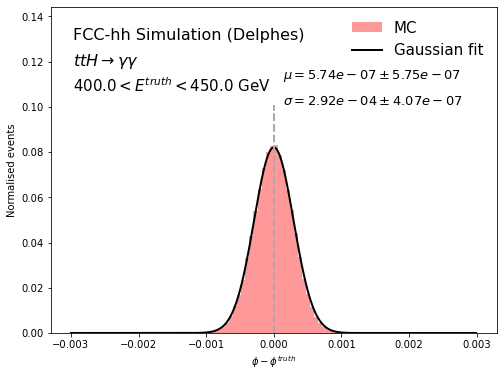

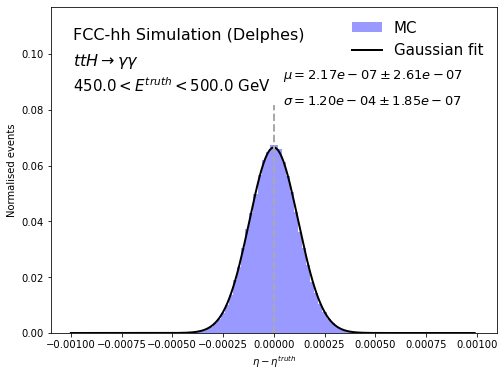

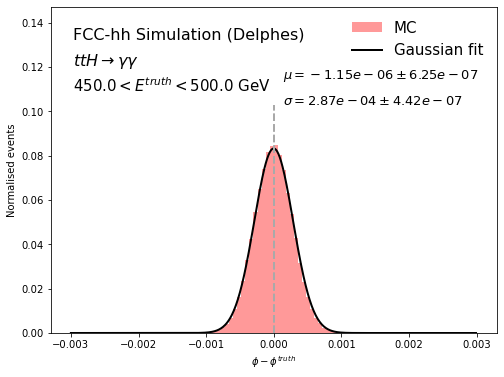

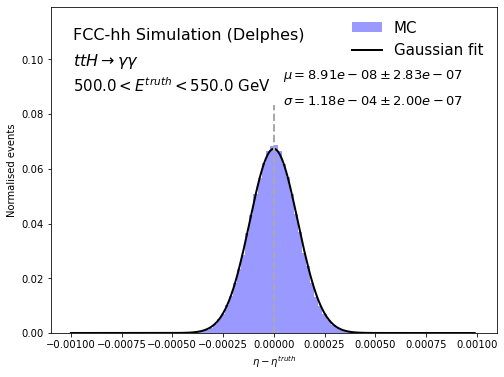

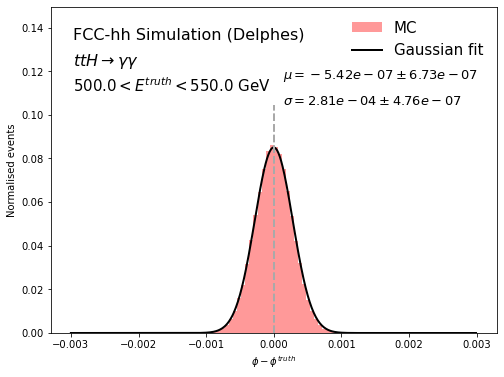

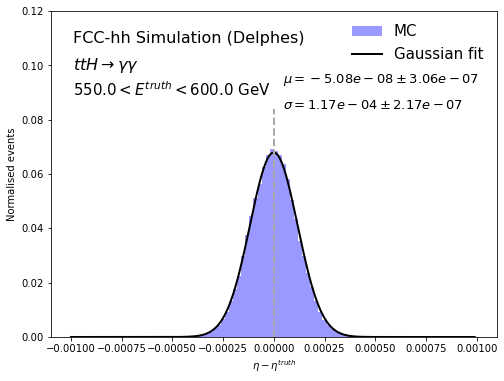

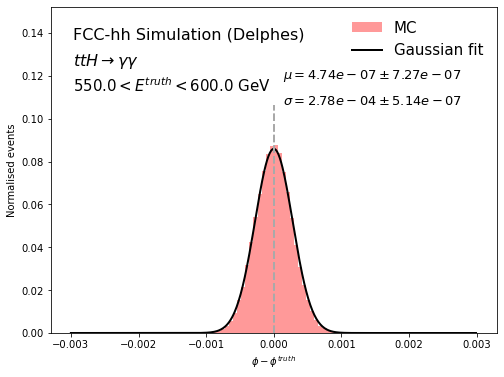

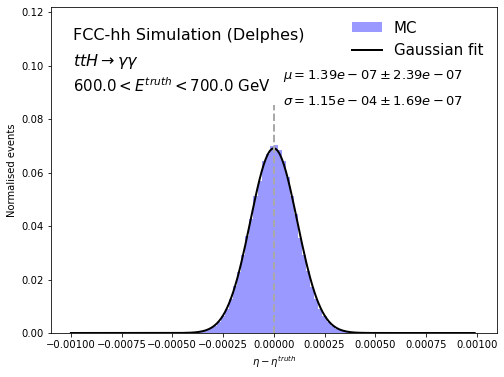

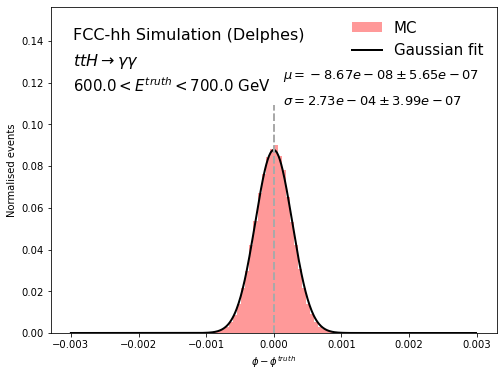

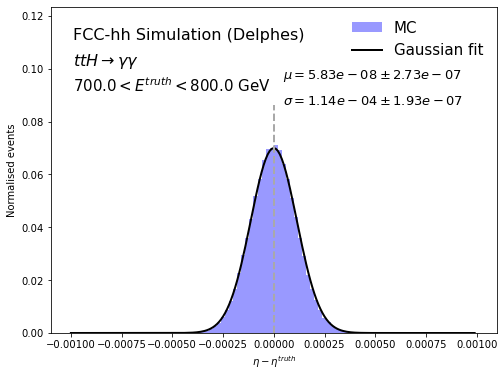

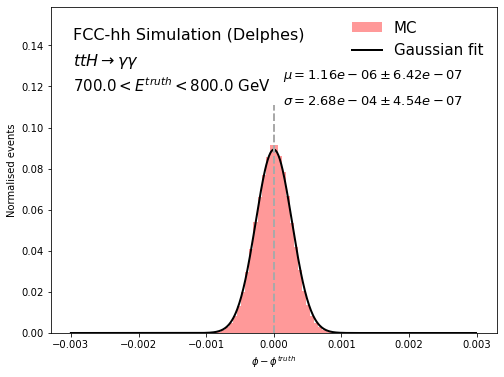

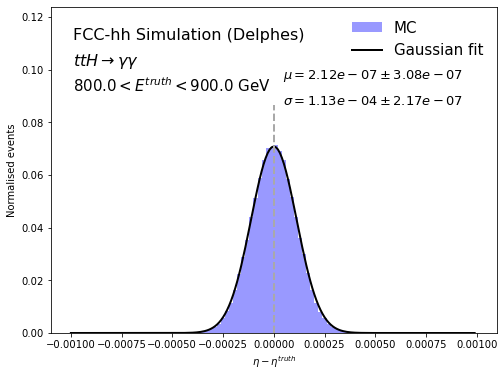

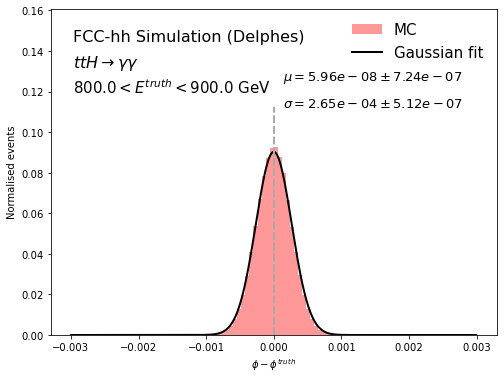

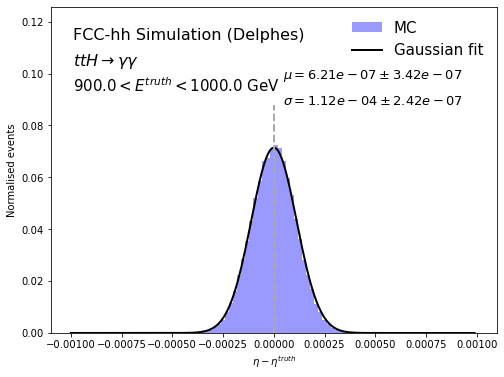

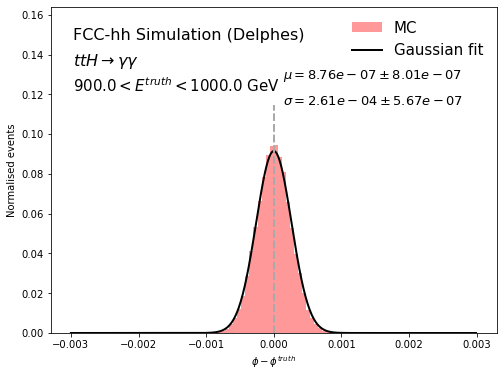

In [27]:
# loop over the energy bins
for ibin in range(1, len(ENERGY_BINS)) :
    
    # bin edges
    i_low = ENERGY_BINS[ibin-1]
    i_up = ENERGY_BINS[ibin]
    
    # select the bin
    df1 = dfss[dfss['energy_bin']==ibin]
    
    # plot eta - etatrue and phi - phitrue
    xeta = df1['eta_y'] - df1['true_eta_y']
    xphi = df1['phi_y'] - df1['true_phi_y']
    xeta = xeta[np.abs(xeta)<1e-3]
    xphi = xphi[np.abs(xphi)<3e-3]
    sigmaeta = np.std(xeta)
    sigmaphi = np.std(xphi)
    
    eta = ROOT.RooRealVar("eta", "eta", -1e-3, 1e-3)
    reta = ROOT.RooDataSet.from_numpy({"eta" : xeta.to_numpy()}, [eta])
    meta = ROOT.RooRealVar("mu_eta", "mu_eta", 0, -1e-3, 1e-3)
    seta = ROOT.RooRealVar("sigma_eta", "sigma_eta", 1e-3, 1e-7, 1e-2)
    geta = ROOT.RooGaussian("gaus_eta", "gaus_eta", eta, meta, seta)
    geta.fitTo(reta)
    
    phi = ROOT.RooRealVar("phi", "phi", -3e-3, 3e-3)
    rphi = ROOT.RooDataSet.from_numpy({"phi" : xphi.to_numpy()}, [phi])
    mphi = ROOT.RooRealVar("mu_phi", "mu_phi", 0, -1e-3, 1e-3)
    sphi = ROOT.RooRealVar("sigma_phi", "sigma_phi", 1e-3, 1e-7, 1e-2) 
    gphi = ROOT.RooGaussian("gaus_phi", "gaus_phi", phi, mphi, sphi)
    gphi.fitTo(rphi)


    # save the std dev of these distributions
    yeta[ibin-1] = seta.getVal()
    yetaerr[ibin-1] = seta.getError()
    yphi[ibin-1] = sphi.getVal()
    yphierr[ibin-1] = sphi.getError() 
    
    # make plots!
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )

    bin_values, bin_edges, _ = ax.hist(xeta,weights = np.ones(len(xeta))/len(xeta),
            bins=100, range=(-0.001,0.001), histtype='stepfilled', color='b', alpha=0.4,
           label='MC')
    bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
    
    # plot gaussian fit
    p0 = [1e-3,meta.getVal(),seta.getVal()] #starting values for the fit
    p1, _ = curve_fit(fit_func,bin_centers,bin_values,p0,maxfev=10000)    
    x_axis = np.arange(-0.001,0.001, 0.00001)
    x_bin = 0.5*(x_axis[1:]-x_axis[:-1])
    ax.plot(x_axis, norm.pdf(x_axis,meta.getVal(),seta.getVal())*p1[0], color='k', lw=2, label='Gaussian fit')

    ax.axvline(0, ymin=0, ymax=0.7, color='darkgrey', ls='--', lw=2.)

    ax.legend(loc='upper right', frameon=False, fontsize=15)
    
    # save gaussian fit values
    ax.text(0.52, 0.78, r"$\mu={:.2e}\pm{:.2e}$".format(meta.getVal(), meta.getError()), transform=ax.transAxes, fontsize=13)
    ax.text(0.52, 0.70, r"$\sigma={:.2e}\pm{:.2e}$".format(sigmaeta, seta.getError()), transform=ax.transAxes, fontsize=13)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<E^{truth}<$"+str(i_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = r"$\eta - \eta^{truth}$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
    plotname = "eta_minus_eta_true_energy_bin_"+str(ibin)
    #plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    #plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    #plt.show()
    
    
    # make plots!
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    bin_values, bin_edges, _ = ax.hist(xphi, weights = np.ones(len(xphi))/len(xphi),
            bins=100, range=(-0.003,0.003), histtype='stepfilled', color='r', alpha=0.4,
                                      label='MC')
    ax.axvline(0, ymin=0, ymax=0.7, color='darkgrey', ls='--', lw=2.)
    bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
    
    # plot gaussian fit
    p0 = [1e-3,mphi.getVal(),sphi.getVal()] #starting values for the fit
    p1, _ = curve_fit(fit_func,bin_centers,bin_values,p0,maxfev=10000)    
    x_axis = np.arange(-0.003,0.003, 0.00001)
    x_bin = 0.5*(x_axis[1:]-x_axis[:-1])
    ax.plot(x_axis, norm.pdf(x_axis,mphi.getVal(),sphi.getVal())*p1[0], color='k', lw=2, label='Gaussian fit')

    ax.axvline(0, ymin=0, ymax=0.7, color='darkgrey', ls='--', lw=2.)

    ax.legend(loc='upper right', frameon=False, fontsize=15)
    
    # save gaussian fit values
    ax.text(0.52, 0.78, r"$\mu={:.2e}\pm{:.2e}$".format(mphi.getVal(), mphi.getError()), transform=ax.transAxes, fontsize=13)
    ax.text(0.52, 0.70, r"$\sigma={:.2e}\pm{:.2e}$".format(sigmaphi, sphi.getError()), transform=ax.transAxes, fontsize=13)
    
    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<E^{truth}<$"+str(i_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = r"$\phi - \phi^{truth}$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
    plotname = "phi_minus_phi_true_energy_bin_"+str(ibin)
    #plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    #plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    #plt.show()
    
    del geta
    del meta
    del seta
    del reta
    del eta
    del gphi
    del mphi
    del sphi
    del rphi
    del phi

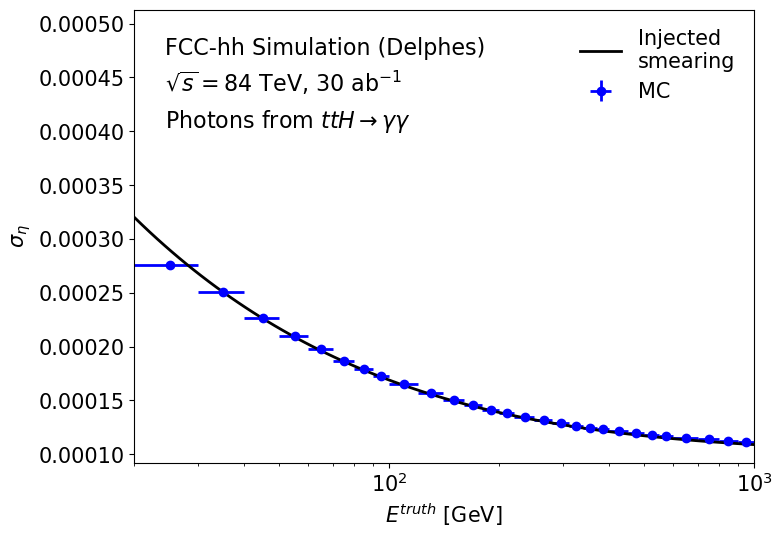

In [33]:
# plot of the resolution for eta
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, yeta, xerr=xerr, yerr=yetaerr, color='b', marker='o', lw=2, ls='none', label='MC')
energy = np.logspace(1, 3, 100)
ax.plot(energy, sigma_eta(energy), color='k', lw=2, label='Injected\nsmearing')

ax.legend(loc='upper right', frameon=False, fontsize=15)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, r"Photons from $ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$E^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\sigma_{\eta}$')

ax.set_xscale("log")
ax.set_xlim(ENERGY_BINS[0], ENERGY_BINS[-1])

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.15)
    
plotname = "sigmaeta_as_a_function_of_energy"
outdir = "/eos/user/e/elmazzeo/ttH@FCC-hh/presentations/"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()  

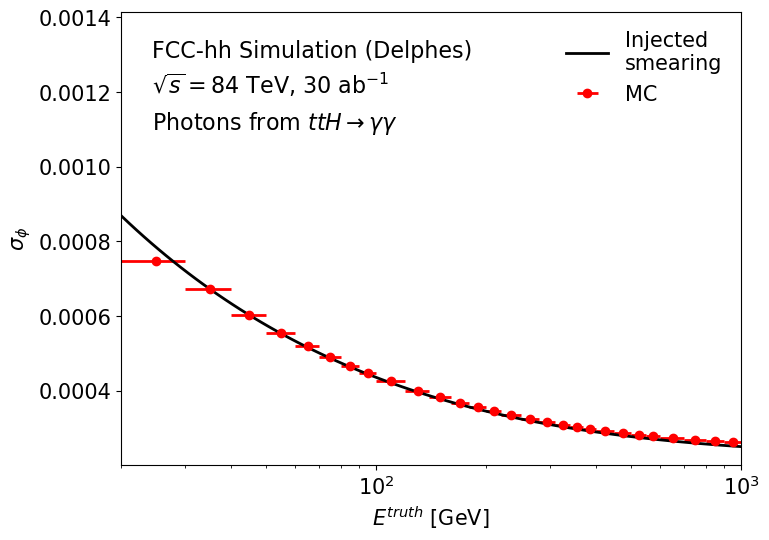

In [34]:
# plot of the resolution for eta
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, yphi, xerr=xerr, color='r', marker='o', lw=2, ls='none', label="MC")
energy = np.logspace(1, 3, 100)
ax.plot(energy, sigma_phi(energy), color='k', lw=2, label="Injected\nsmearing")

ax.legend(loc='upper right', frameon=False, fontsize=15)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, r"Photons from $ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$E^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\sigma_{\phi}$')

ax.set_xscale("log")
ax.set_xlim(ENERGY_BINS[0], ENERGY_BINS[-1])

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.15)
    
plotname = "sigmaphi_as_a_function_of_energy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

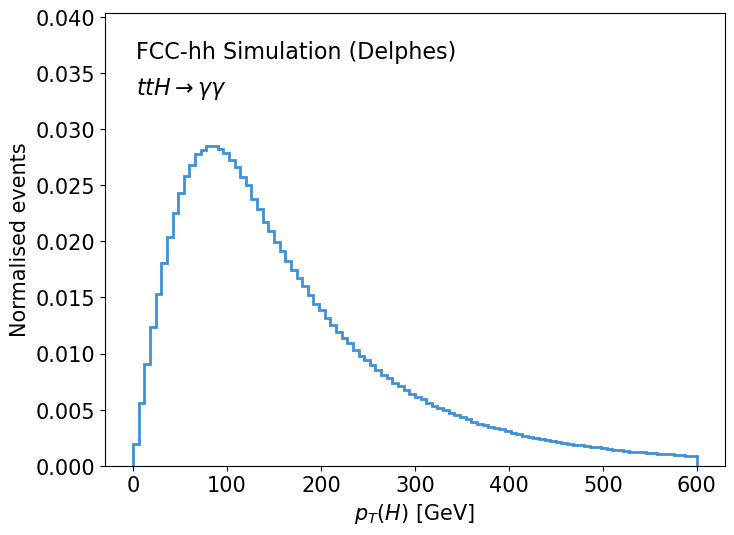

In [33]:
# make plot of pT(Higgs)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.hist(dfs['pT_higgs'], weights=dfs['weight']/dfs['weight'].sum(),
        bins=100, range=(0,600), color=color_sequence[0], histtype='step',
        lw=2)


ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T(H)$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "pT_higgs"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()  

In [117]:
PT_BINS = np.array([0,10,20,30,40,50,60,70,80,90,100,
              120,140,160,180,200,220,250,280,
               310,340,370,400,450,500,550,600,
              700,800,900,1000], dtype=np.float64)
x = 0.5*(PT_BINS[1:] + PT_BINS[:-1])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

In [118]:
dfs['pT_bins'] = np.digitize(dfs['pT_higgs'], PT_BINS)

In [35]:
def interquartile(data, w=None):
    "interquartile(data, w=None) -> interquartile range"
    N = len(data)
    if not N:
        return np.nan, 0.
    iqr = np.diff(np.quantile(data, [0.25, 0.75]) )
    if w is not None:
        N = 1. * w.sum() ** 2 / (w ** 2).sum()  # effective entries
    return iqr, 1.166 * iqr / np.sqrt(N)  # 1.166 = 1.573 / 1.349, http://stats.stackexchange.com/questions/110902/error-on-interquartile-range


def interquartileEff(data, w=None):
    """interquartileEff(data, w=None) -> interquartile range divided by 1.349
       (to convert to sigma for a gaussian)"""
    iqr = interquartile(data, w)
    return iqr[0] / 1.349, iqr[1] / 1.349

0.7772481026165216 0.005982021276075399


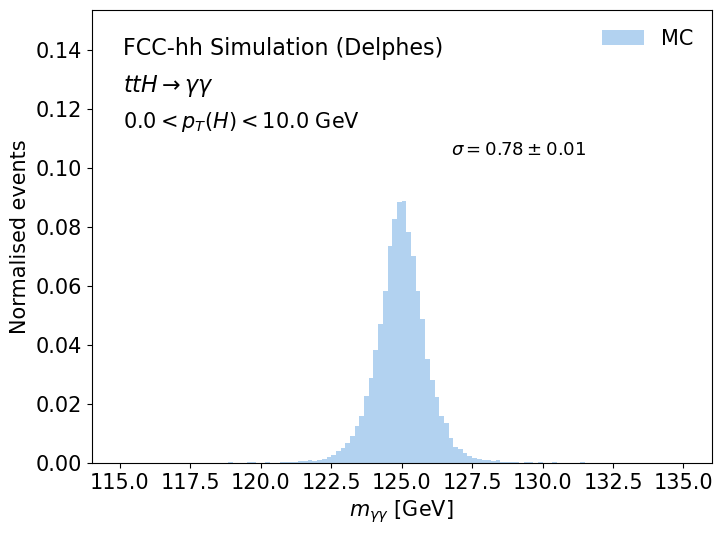

0.7595135778564273 0.0034334073369901882


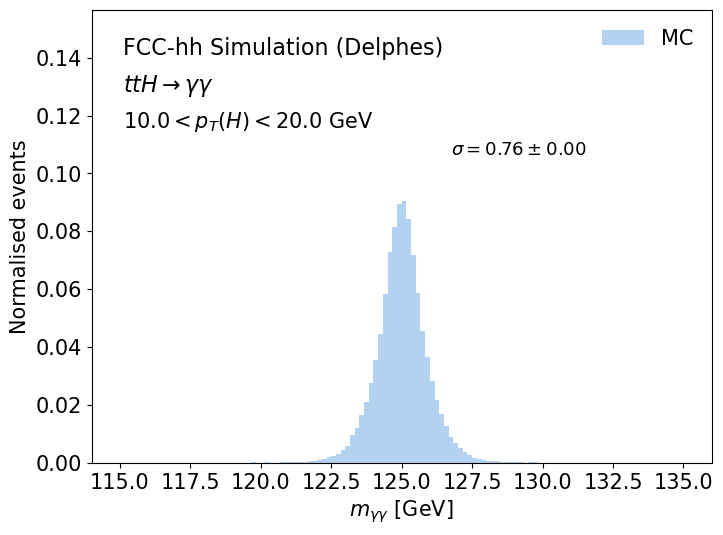

0.7632858581769193 0.0027554306713434874


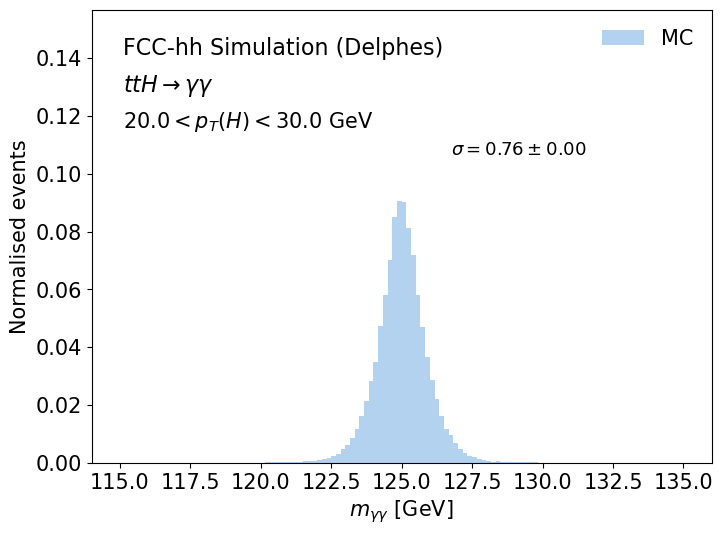

0.7535455136762185 0.00237433115679508


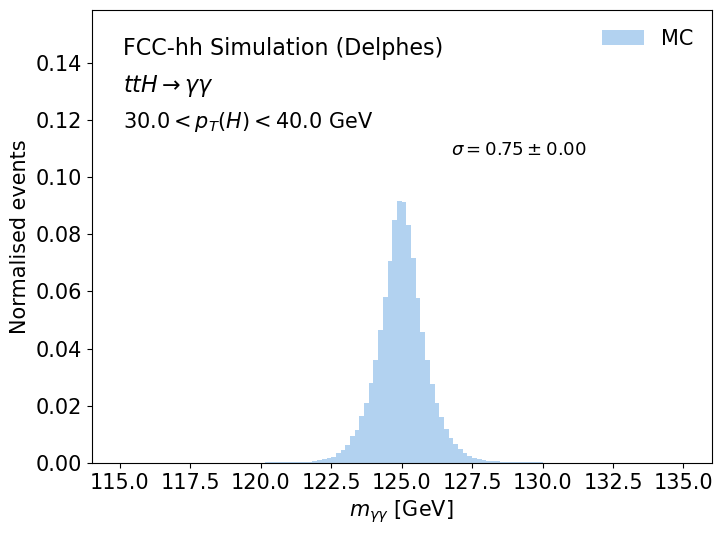

0.7563110984988881 0.0021786779118061613


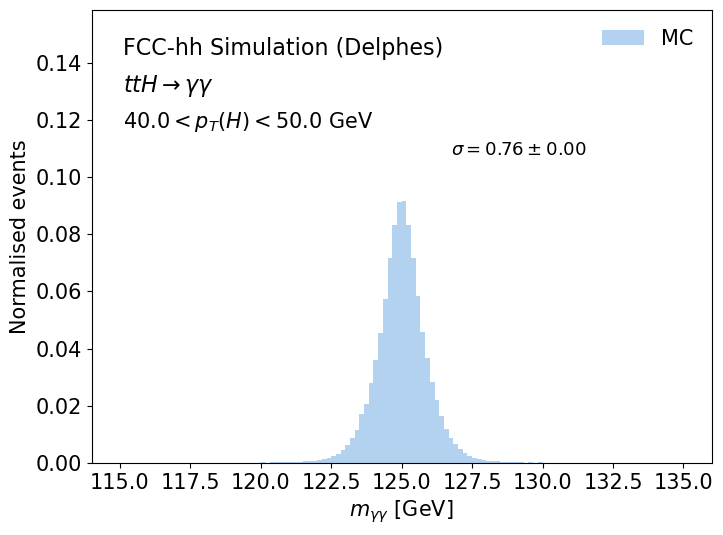

0.7499839041832203 0.00203827935634091


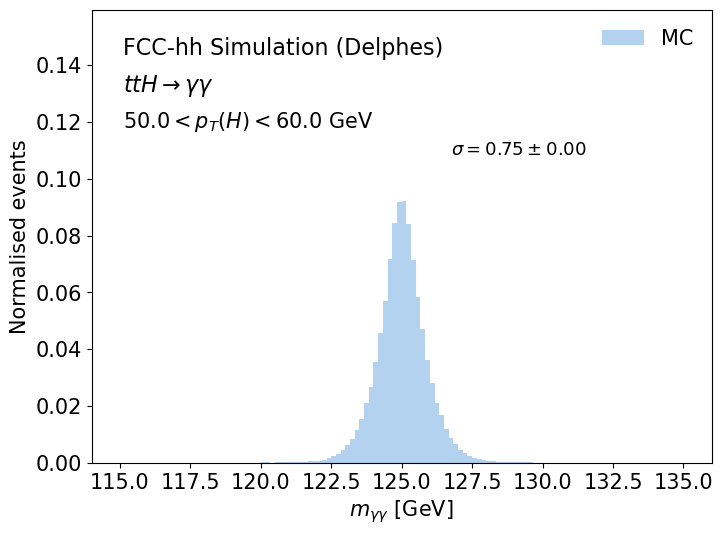

0.7456927232339349 0.0019564628560417526


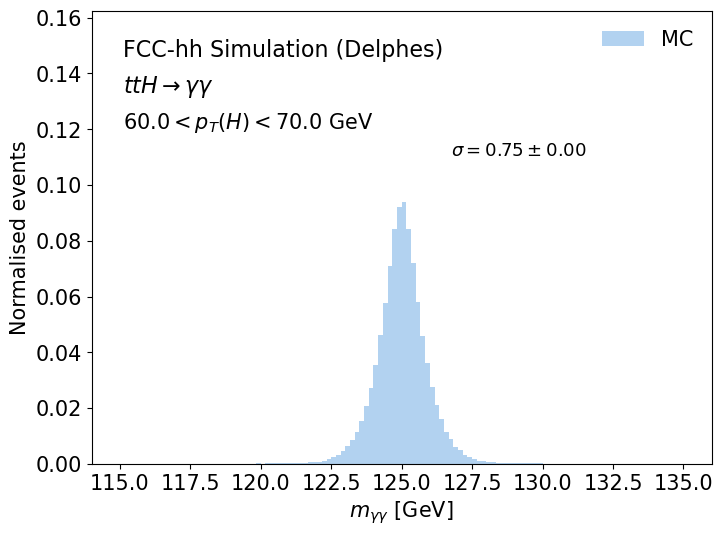

0.7412332884022887 0.001910787210081139


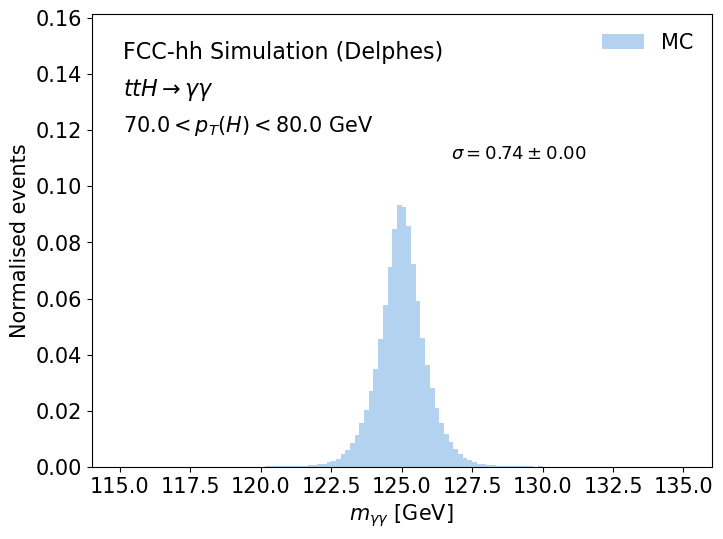

0.7305753239885447 0.001872403130035813


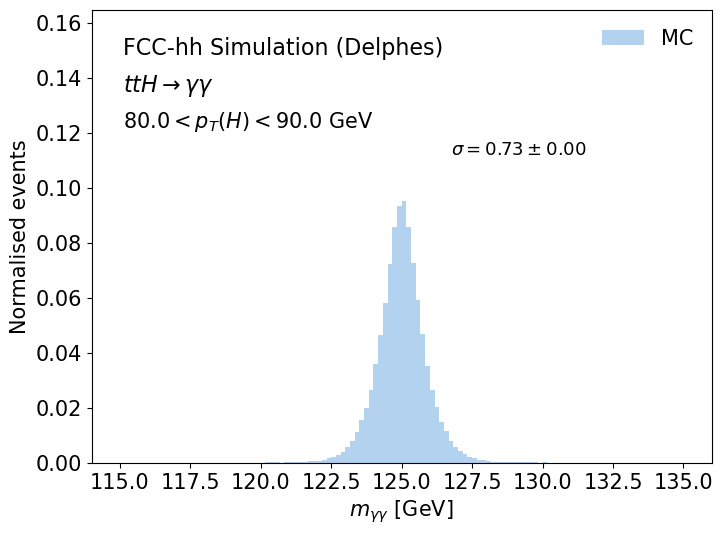

0.721134725900117 0.0018591806360438903


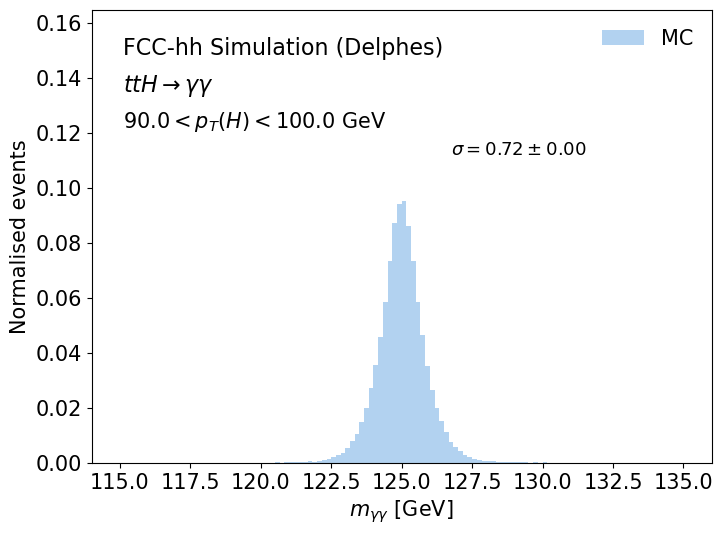

0.7070282638470626 0.0013247382620850256


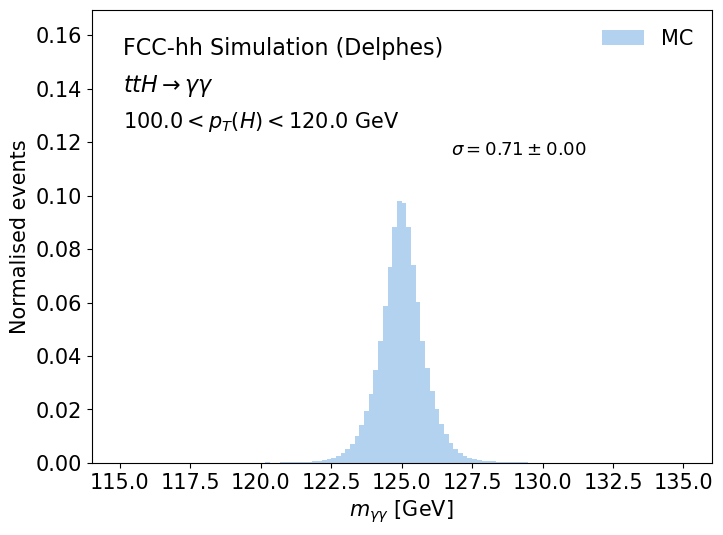

0.6729094870802735 0.0013368052812419413


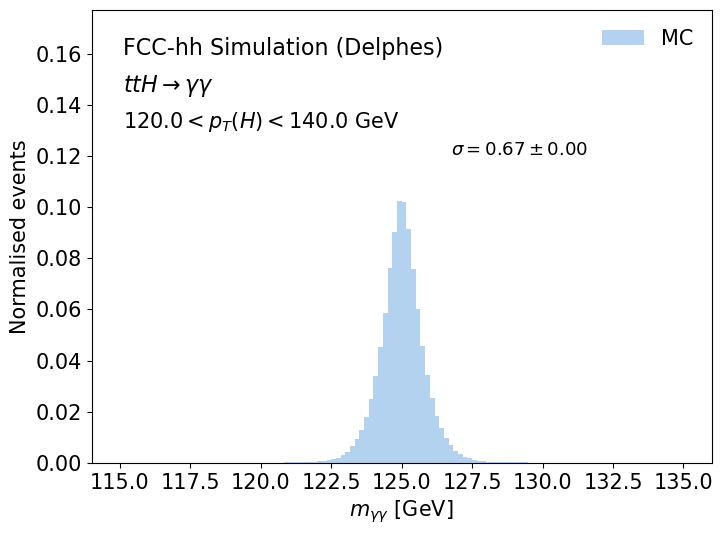

0.6470733257997823 0.0013851644131483995


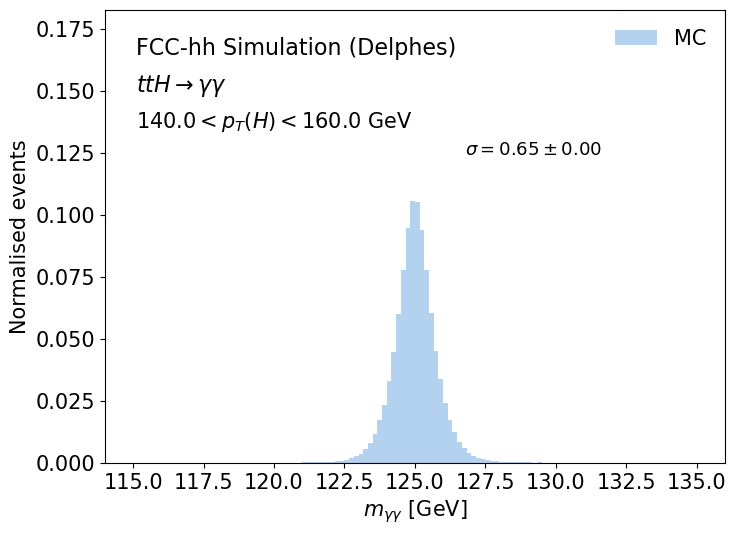

0.6199222392201689 0.0014278251261068695


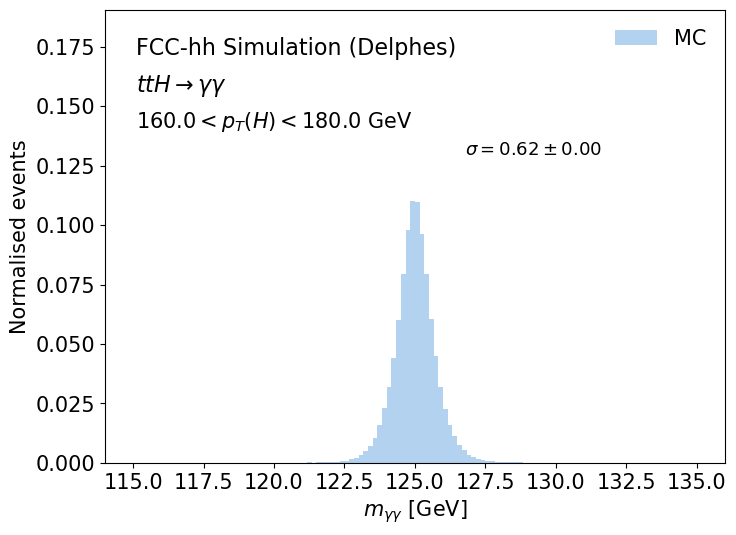

0.5994461659063137 0.0014924225334298595


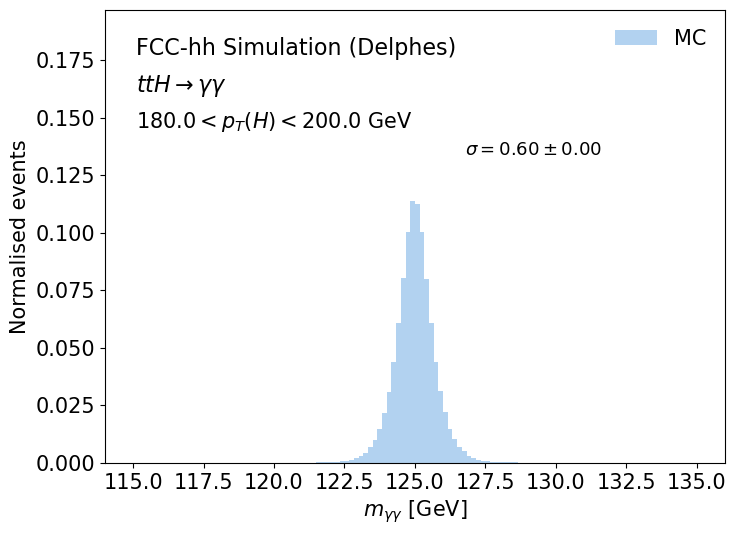

0.5778403879537505 0.0015578694840646965


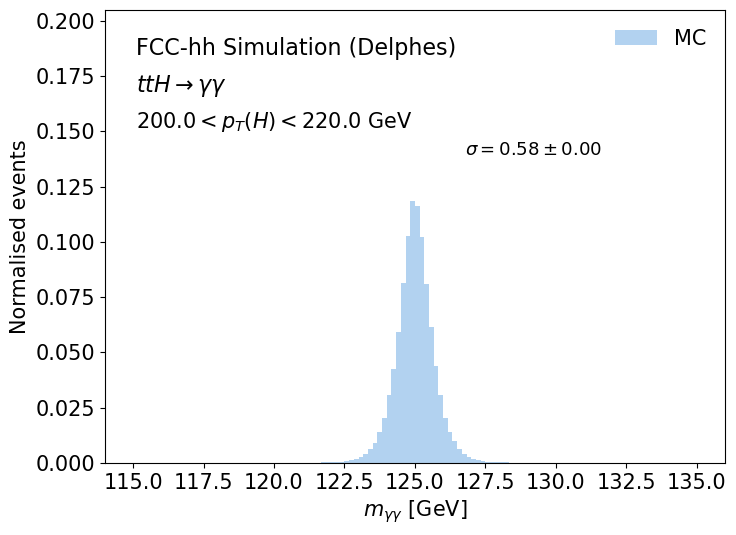

0.557901595944913 0.0013565997221743529


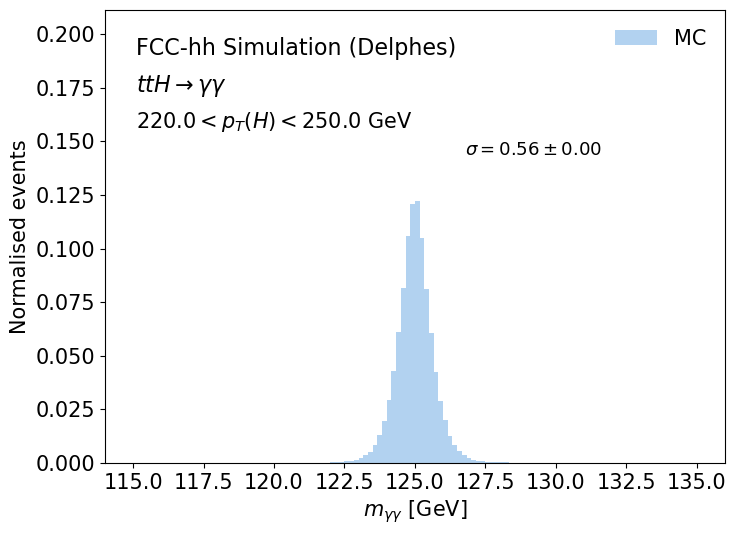

0.5374849063542438 0.0014711319736814444


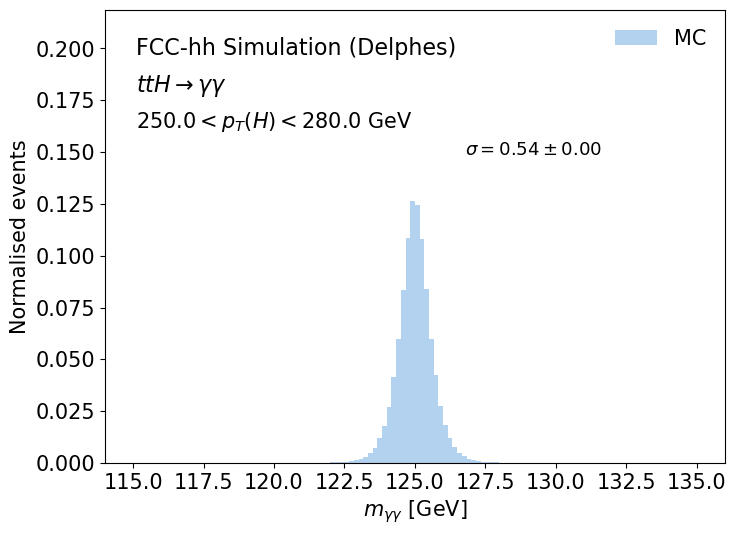

0.5190109128506648 0.001596112726589642


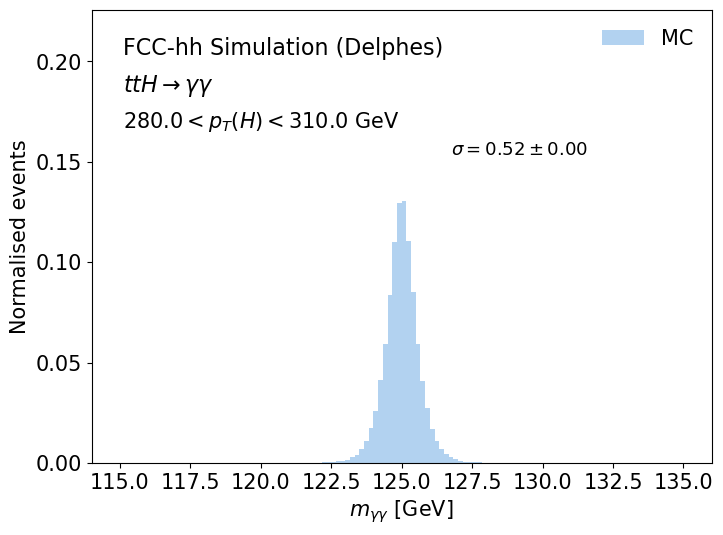

0.5048493087689376 0.0017435123764830234


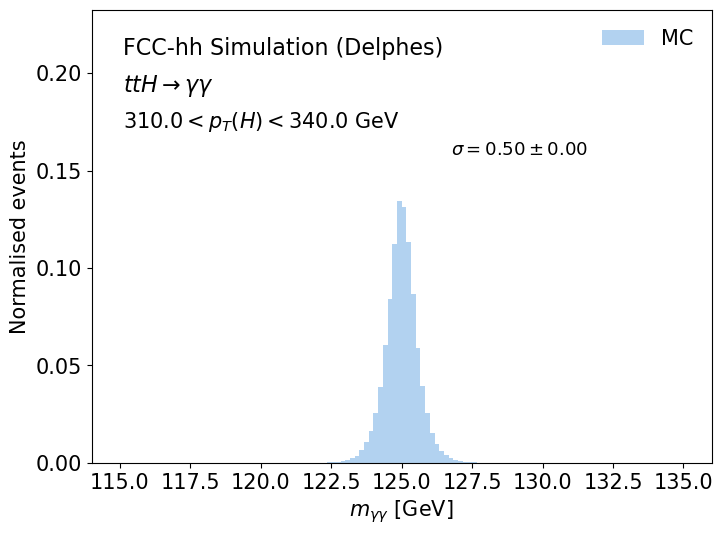

0.48794757003162065 0.0018812401569908521


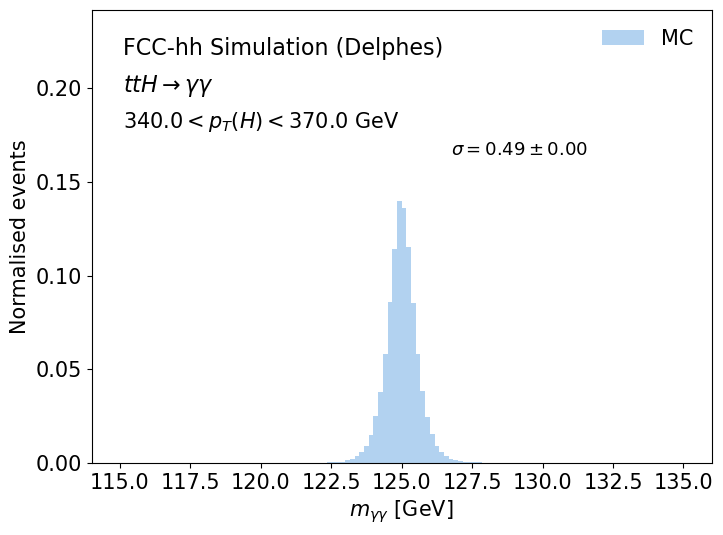

0.4786243254913941 0.002053930325980567


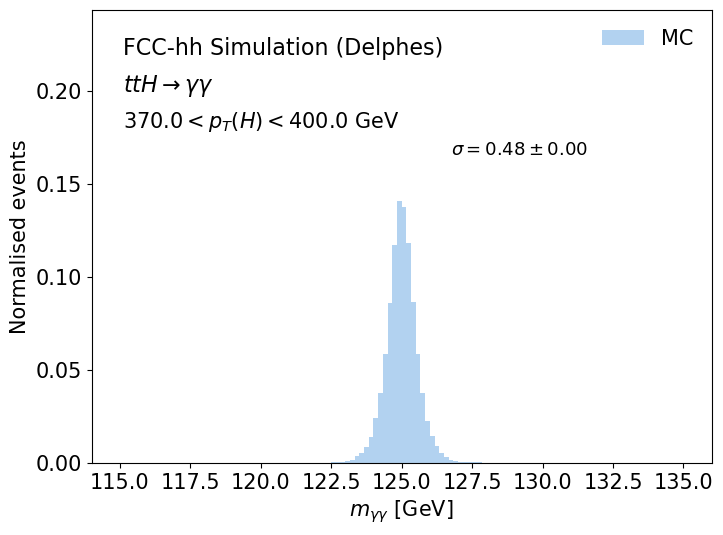

0.462264109753608 0.001761456563390338


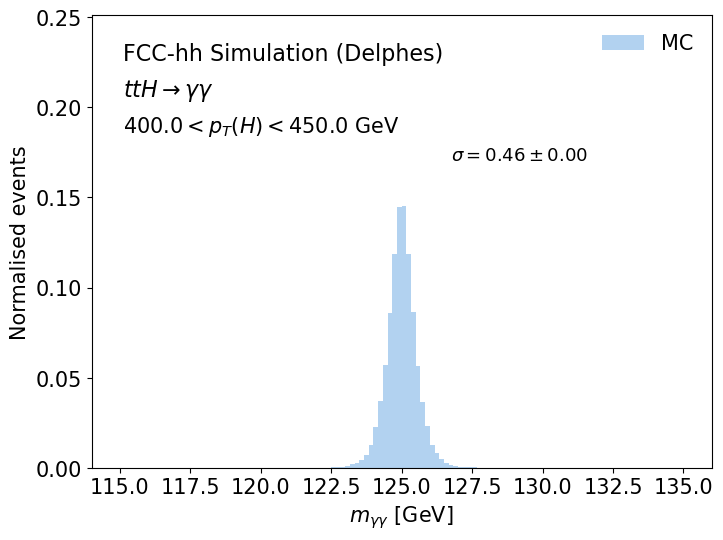

0.44942167266551614 0.0020170504524634016


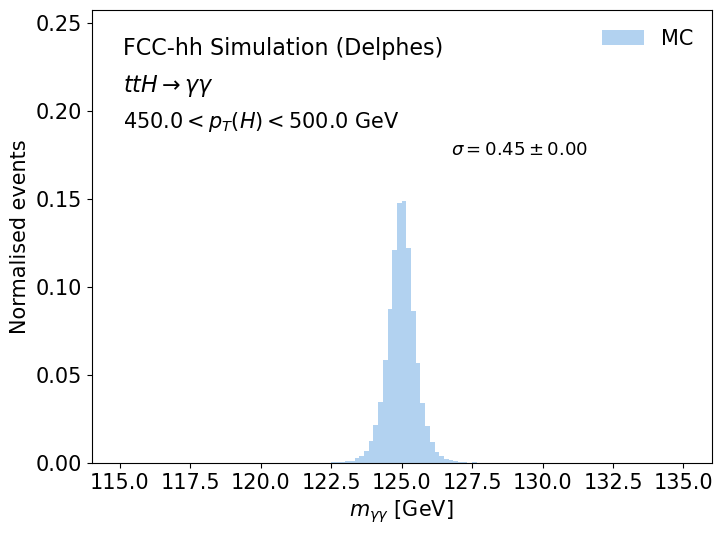

0.4340130103968796 0.0022885956795339795


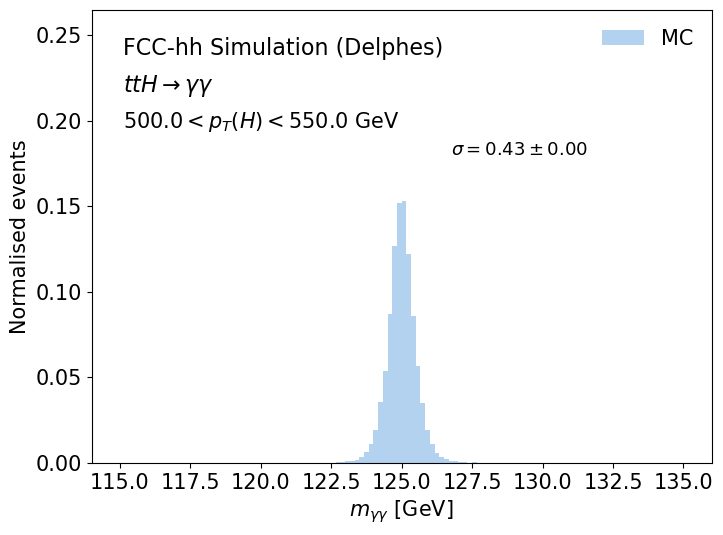

0.4262987819753637 0.0026056474076610555


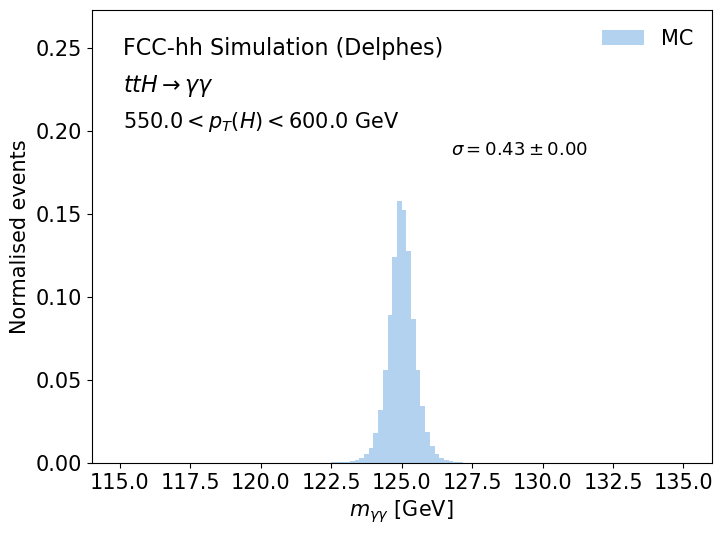

0.4138762726440882 0.002209256627521668


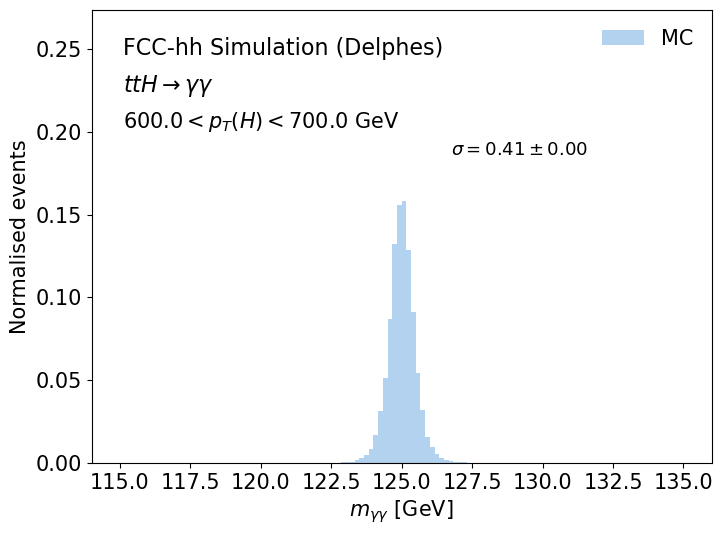

0.4029836011339418 0.0028074618605218944


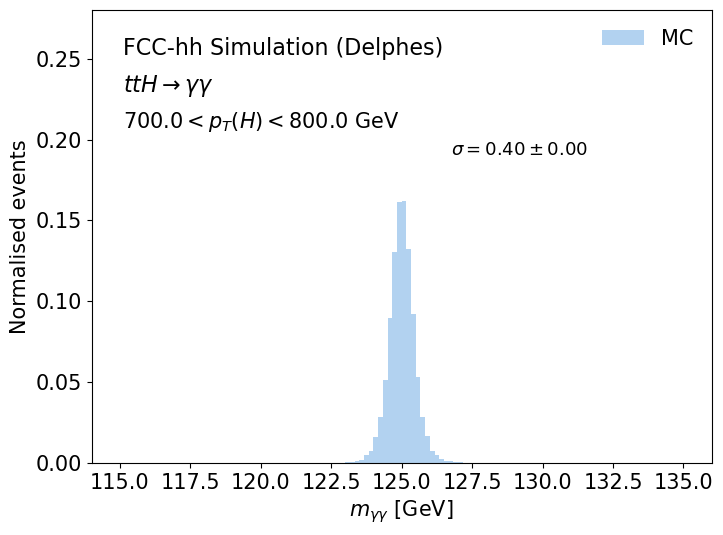

0.39936684961227065 0.004019855910964029


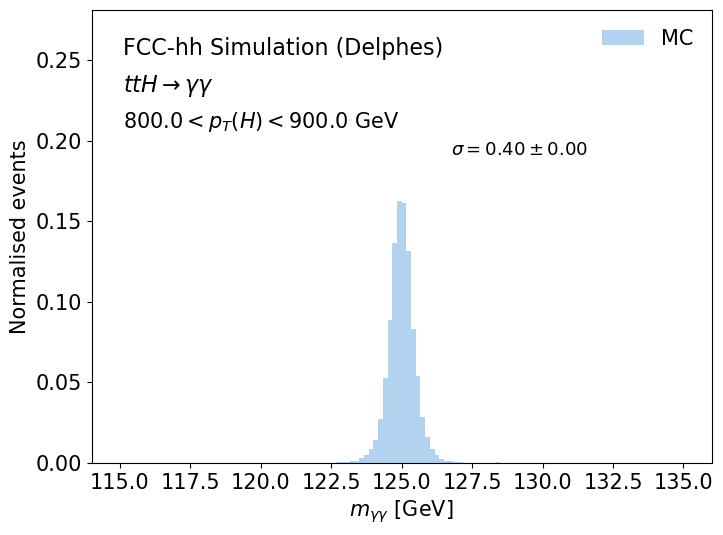

0.43375002533705526 0.007031805091263091


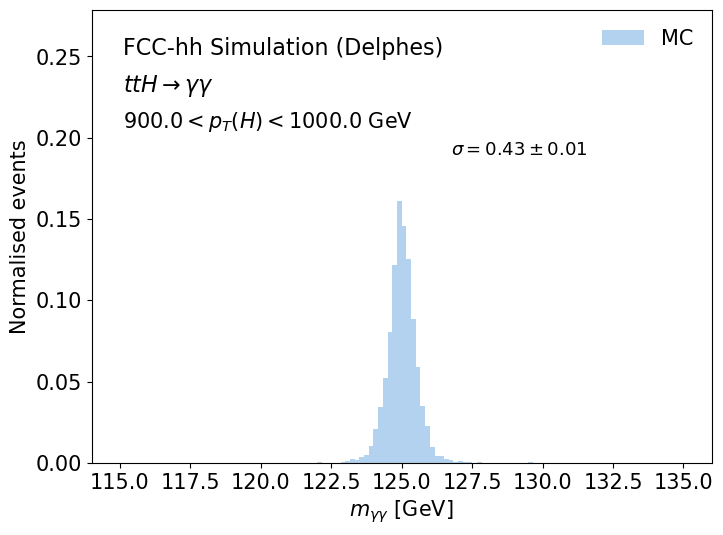

In [123]:
# loop over the energy bins
for ibin in range(1, len(PT_BINS)) :
    
    # bin edges
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
    
    # select the bin
    df1 = dfs[dfs['pT_bins']==ibin]
    df1 = df1.query("(m_yy>110.) & (m_yy<140.)")

    # plot eta - etatrue and phi - phitrue
    xmass = df1['m_yy'].to_numpy()

    # fit the myy distribution 
    #param_values, param_errors = get_gaussian_fit(xmass, np.ones(len(xmass))/len(xmass))
    #print(param_values, param_errors)
    iqr, iqr_err = interquartileEff(xmass)
    #iqr = np.std(xmass)
    iqr_err = iqr_err[0]
    iqr = iqr[0]
    
    # save the std dev of these distributions
    y[ibin-1] = iqr
    yerr[ibin-1] = iqr_err
    print(iqr, iqr_err)
    # make plots!
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )

    bin_values, bin_edges, _ = ax.hist(xmass,weights = np.ones(len(xmass))/len(xmass),
            bins=120, range=(115,135), histtype='stepfilled', color=color_sequence[0], alpha=0.4,
           label='MC')
    bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
    
    # plot gaussian fit
    left = param_values[2] * (-1.) + param_values[1]
    right = param_values[2] * (2.5) + param_values[1]
    x_axis = np.arange(param_values[1]-param_values[2]*2,param_values[1]+param_values[2]*2, 0.02)
    #ax.plot(x_axis, norm.pdf(x_axis,param_values[1],param_values[2])*param_values[0]*(right-left)/20./0.01, color='k', lw=2, label='Gaussian fit')

    ax.legend(loc='upper right', frameon=False, fontsize=15)
    
    # save gaussian fit values
    #ax.text(0.58, 0.76, r"$\mu={:.2f}\pm{:.2f}$".format(param_values[1],param_errors[1]), transform=ax.transAxes, fontsize=13)
    ax.text(0.58, 0.68, r"$\sigma={:.2f}\pm{:.2f}$".format(iqr,iqr_err), transform=ax.transAxes, fontsize=13)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<p_T(H)<$"+str(i_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = r"$m_{\gamma\gamma}$ [GeV]"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
    plotname = "myy_pTH_bin_"+str(ibin)
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()


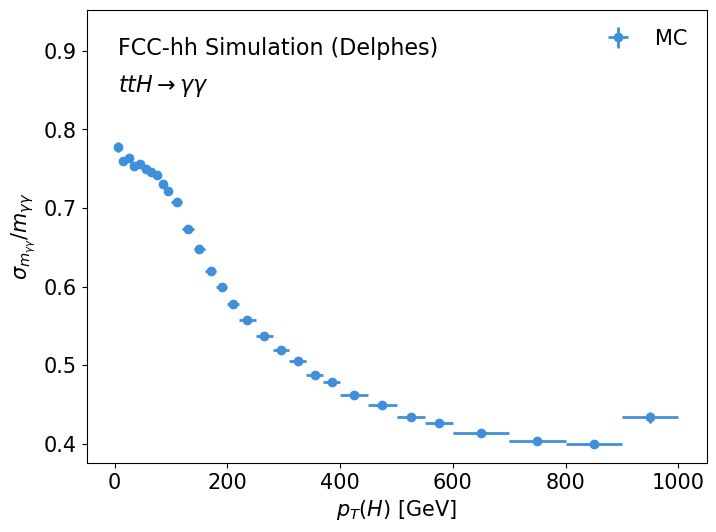

In [150]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], marker='o', lw=2, ls='none', label='MC')
#energy = np.logspace(1, 3, 100)
#ax.plot(energy, sigma_eta(energy), color='k', lw=2, label='Injected\nsmearing')

ax.legend(loc='upper right', frameon=False, fontsize=15)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T(H)$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\sigma_{m_{\gamma\gamma}}/m_{\gamma\gamma}$')

#ax.set_xscale("log")
#ax.set_xlim(ENERGY_BINS[0], ENERGY_BINS[-1])

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "myy_resolution_as_a_function_of_pTH"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()  

In [37]:
ENERGY_BINS = np.array([20,30,40,50,60,70,80,90,100,
              120,140,160,180,200,220,250,280,
               310,340,370,400,450,500,550,600,
              700,800,900,1000], dtype=np.float64)
x = 0.5*(ENERGY_BINS[1:] + ENERGY_BINS[:-1])
xerr = 0.5*(ENERGY_BINS[1:] - ENERGY_BINS[:-1])
dfss['energy_bin'] = np.digitize(dfss['true_E_y'], ENERGY_BINS)
y = np.zeros(len(ENERGY_BINS)-1)
yerr = np.zeros(len(ENERGY_BINS)-1)

/tmp/elmazzeo/ipykernel_563226/1455894145.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 788 out-of-range events
[#1] INFO:Fitting -- RooAbsPdf::fitTo(gaus_mass_over_gaus_mass_Int[mass]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_gaus_mass_over_gaus_mass_Int[mass]_) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
RooAbsMinimizerFcn: Minimized function has error status.
Returning maximum FCN so far (-76184.9) to force MIGRAD to back out of this region. Error log follows.
Parameter values: 	mu_mass=0	sigma_mass=0.00307964
RooAbsPdf::gaus_mass_over_gaus_mass_Int[mass][ numerator=gaus_mass denominator=gaus_mass_Int[mass] ]
     getLogVal() top-level p.d.f not greater than zero @ numerator=gaus_mass=1, denominator=gaus_mass_Int[mass]=0.0077195
     g

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =      -79038.54606 Edm =       3665006.831 NCalls =      9
Info in <Minuit2>: NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : -132035.1907
  Edm           : 564.3309864
  Internal parameters:	[                0    -0.6746308869]	
  Internal gradient  :	[     -388193.3412      2943.166148]	
  Internal covariance matrix:
[[   1.468618e-08              0]
 [              0  5.1030381e-06]]]
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : -132035.1907
  Edm           : 564.3309864
  Internal parameters:	[                0    -0.6746308869]	
  Internal gradient  :	[     -388193.3412      2943.166148]	
  Internal covariance matrix:
[[   1.468618e-08              0]
 [              0  5.1030381e-06]]]
Info i

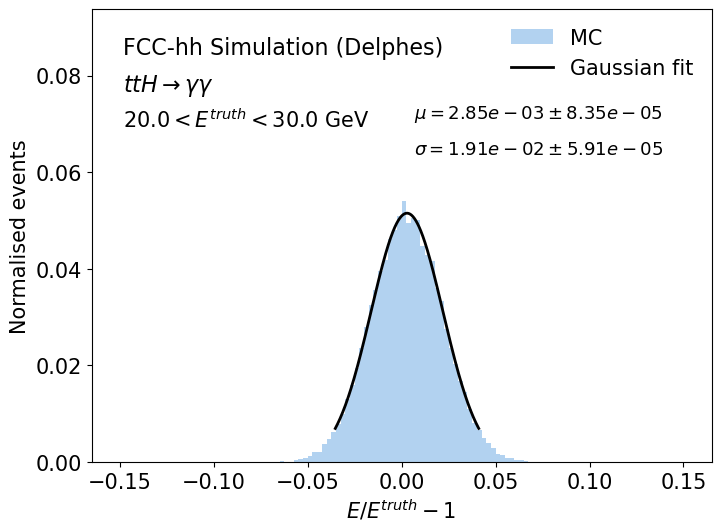

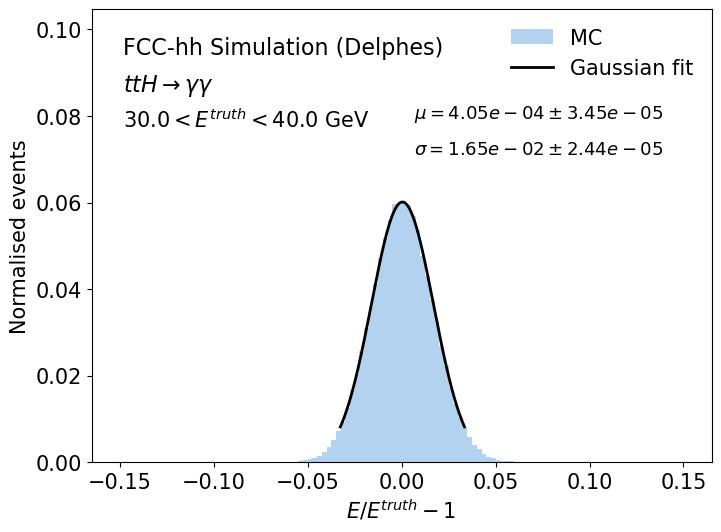

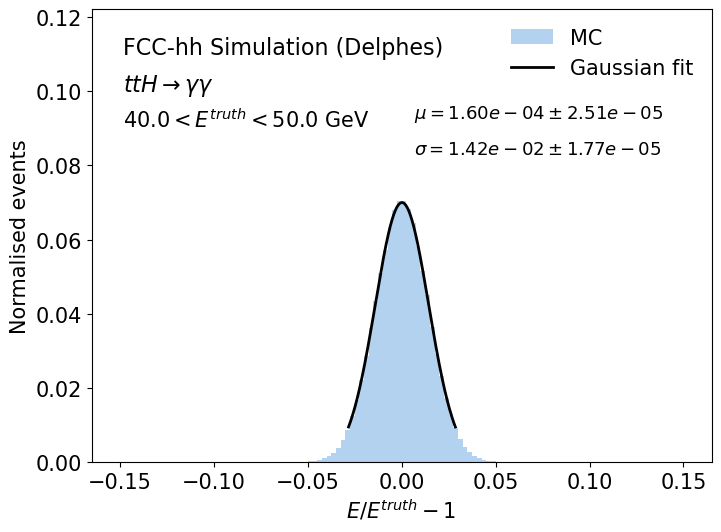

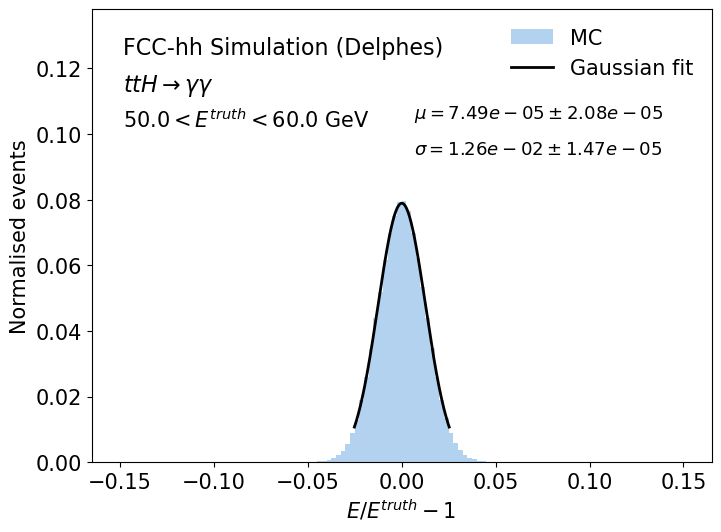

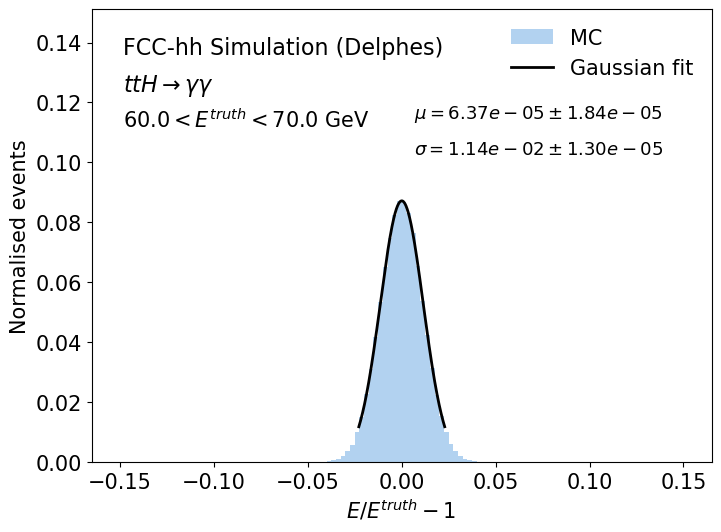

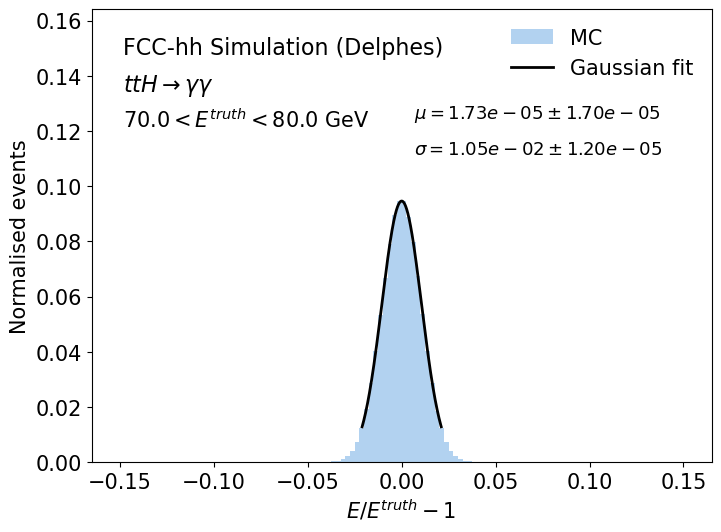

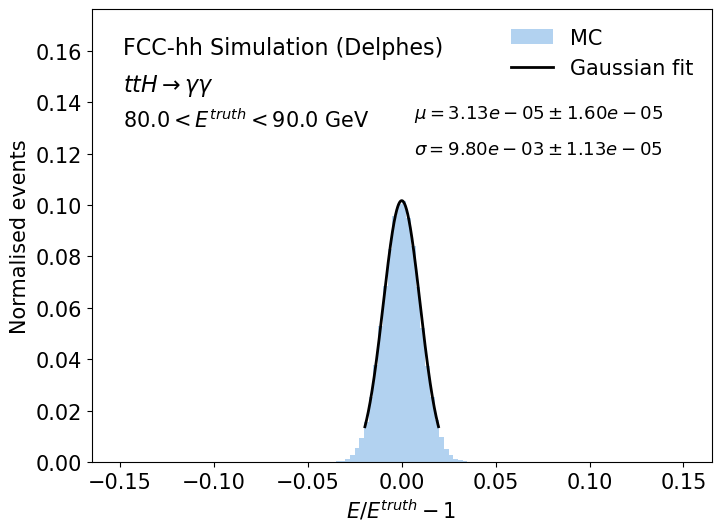

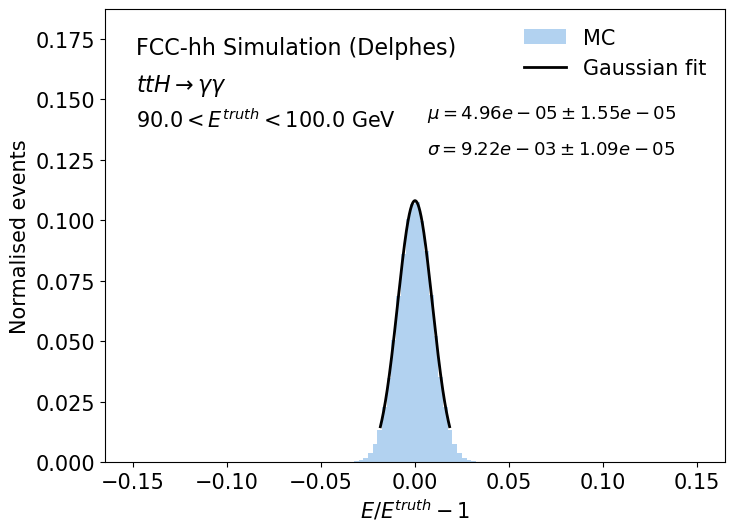

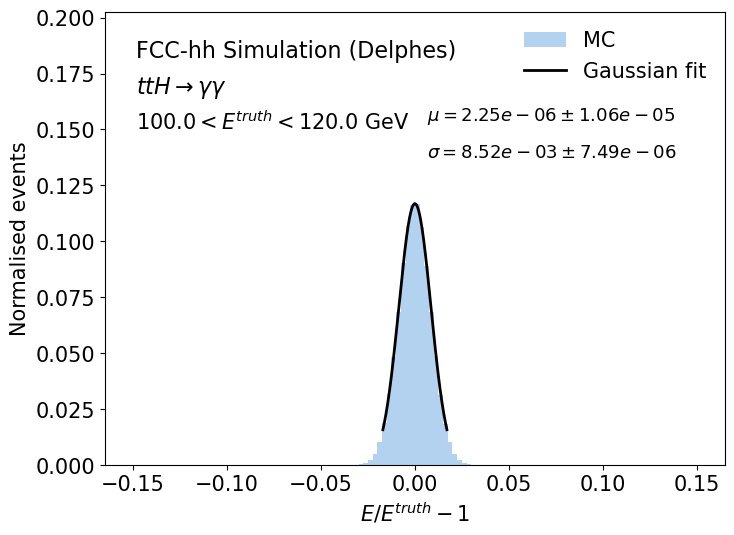

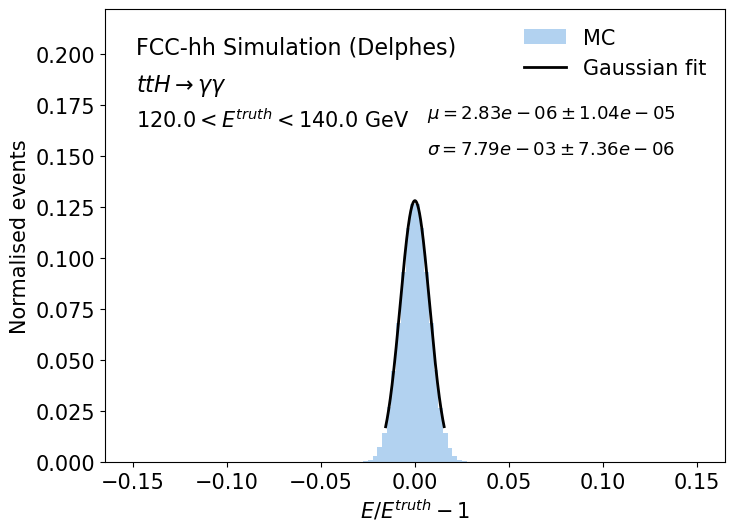

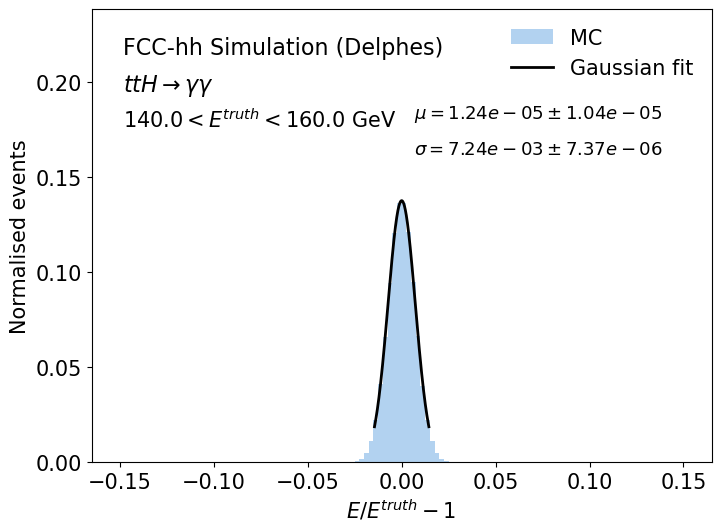

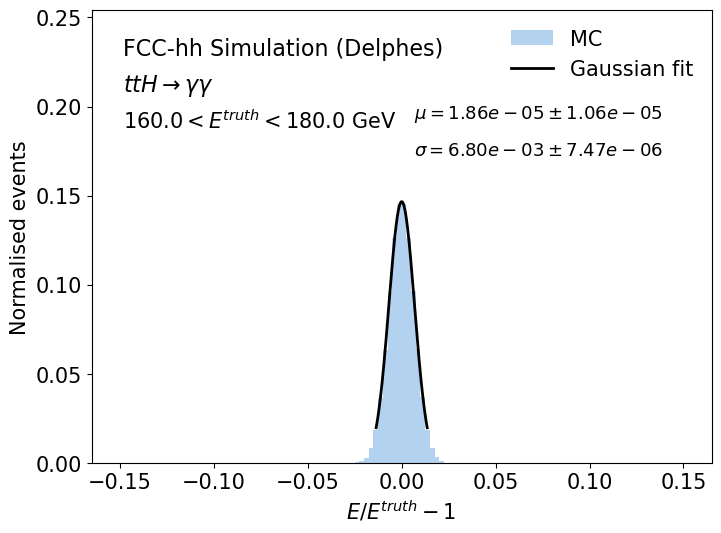

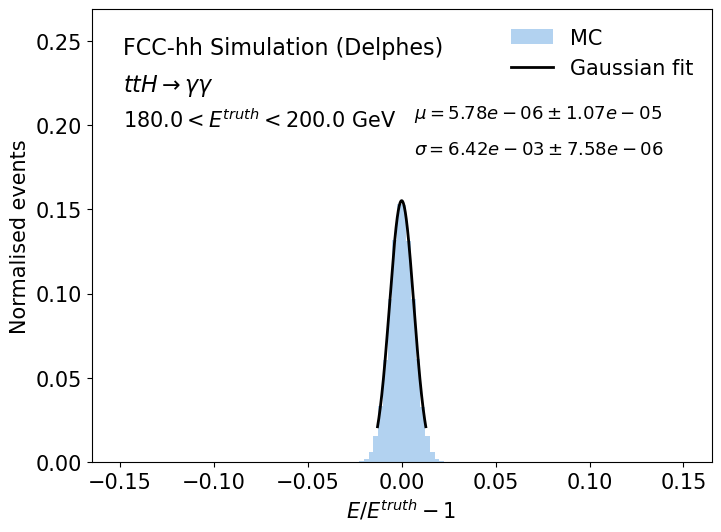

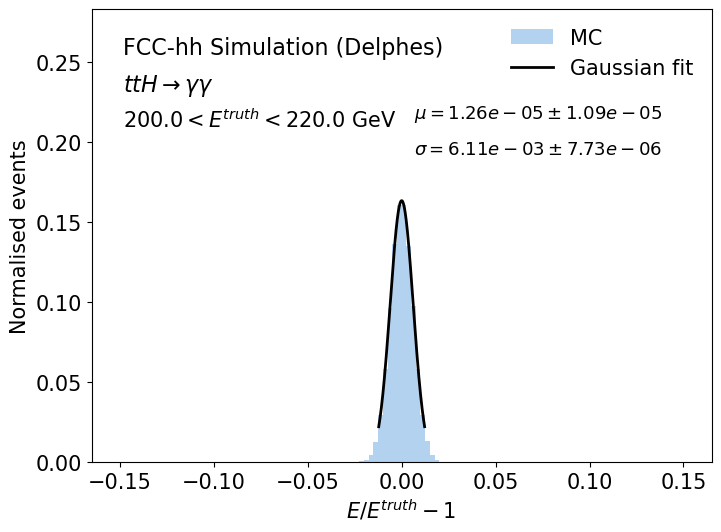

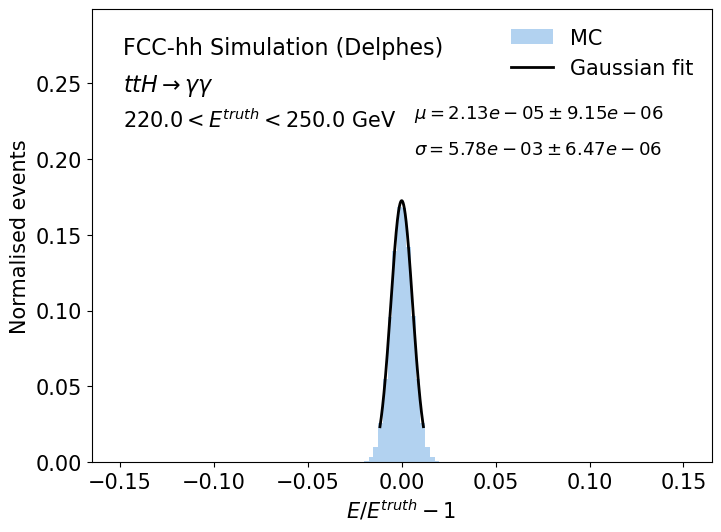

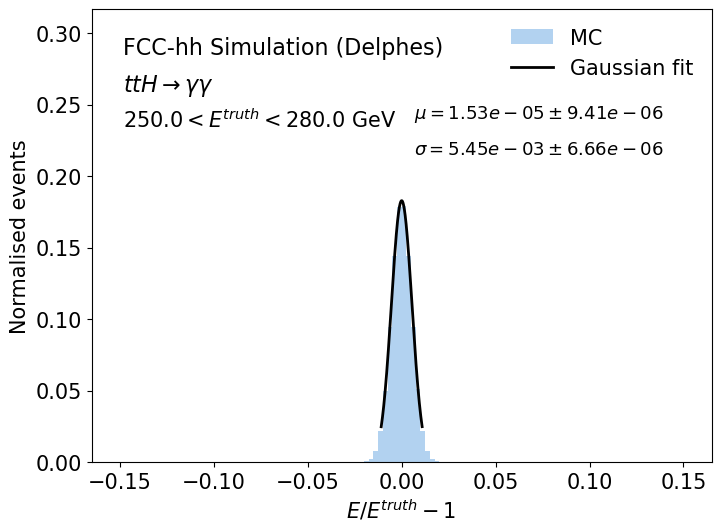

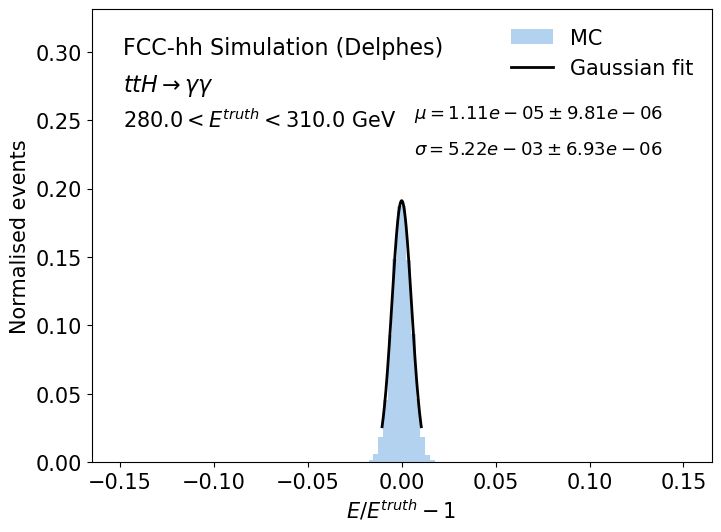

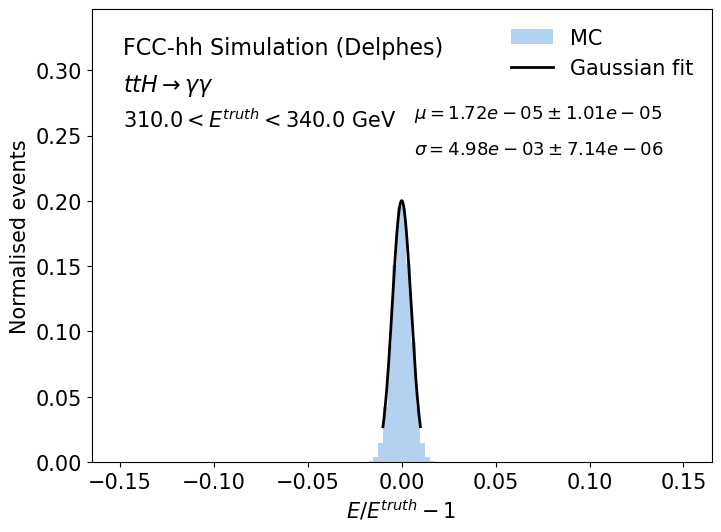

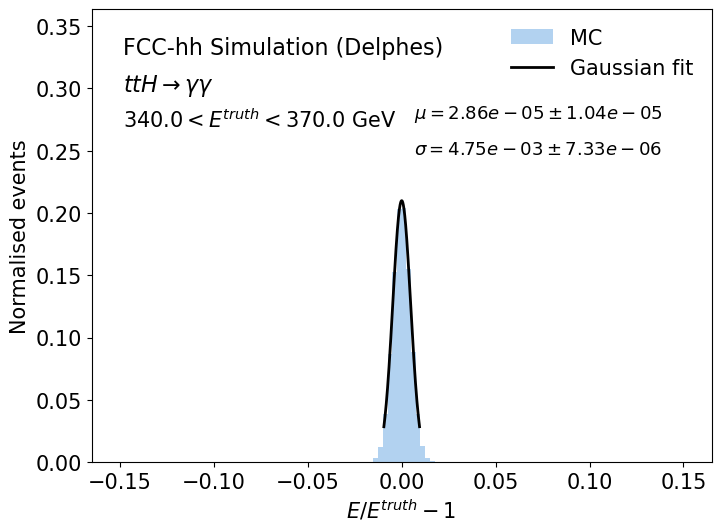

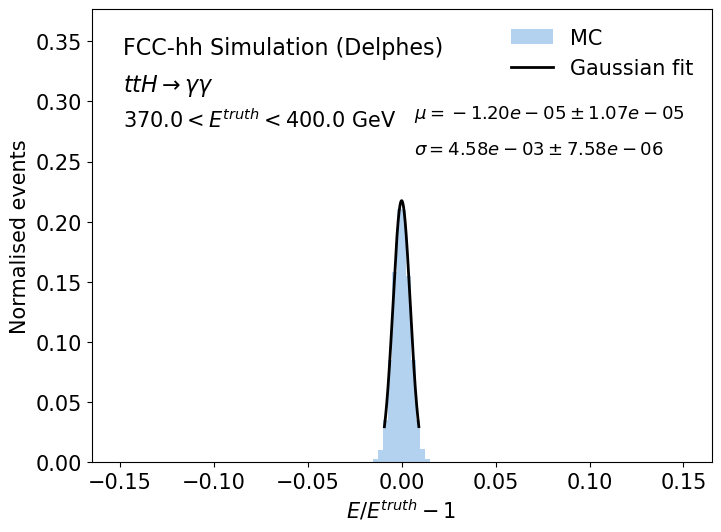

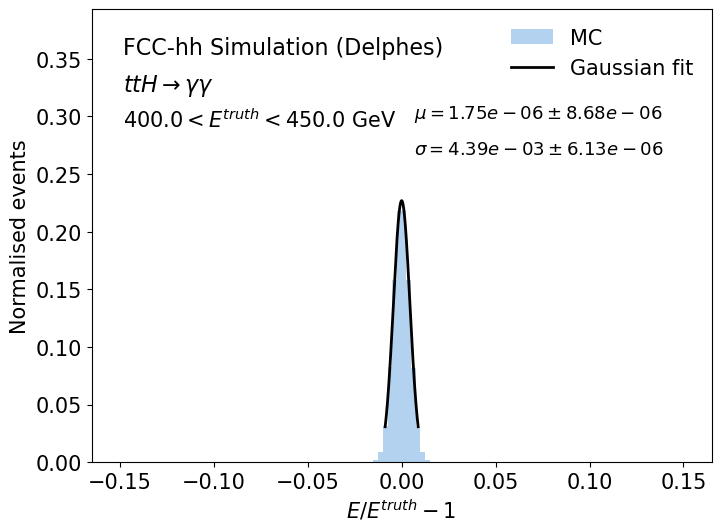

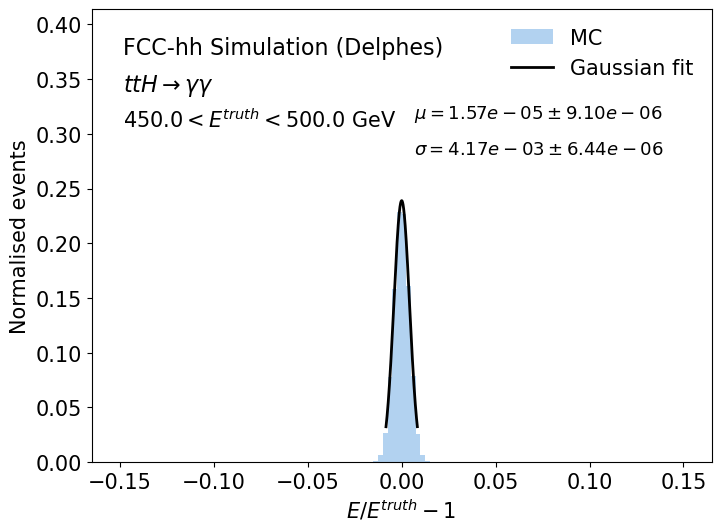

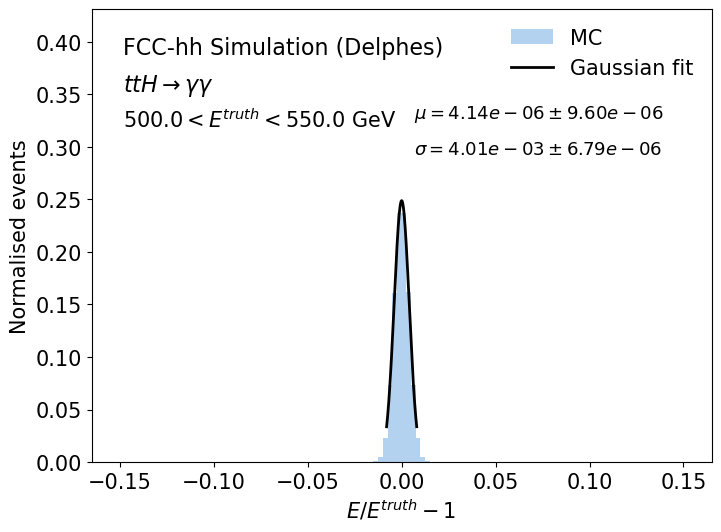

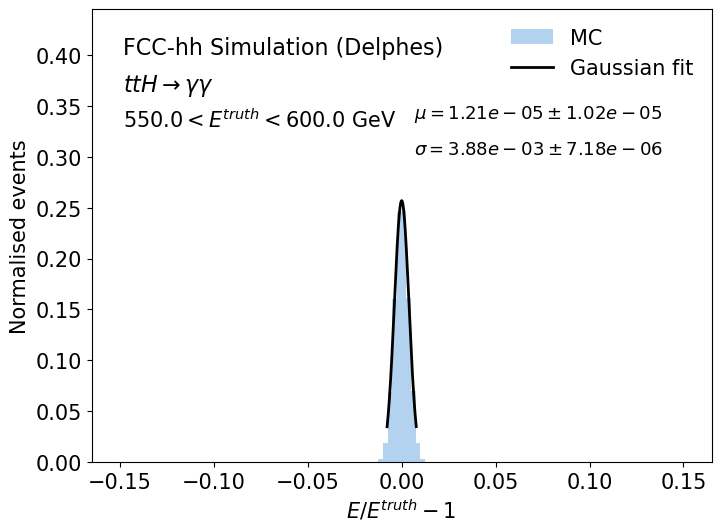

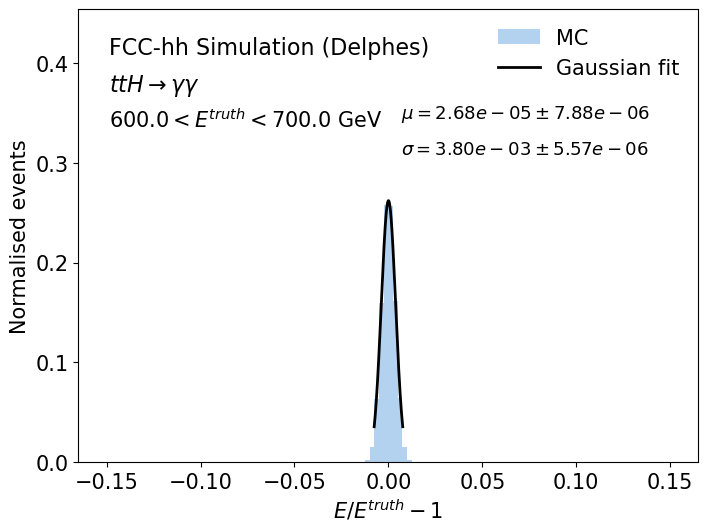

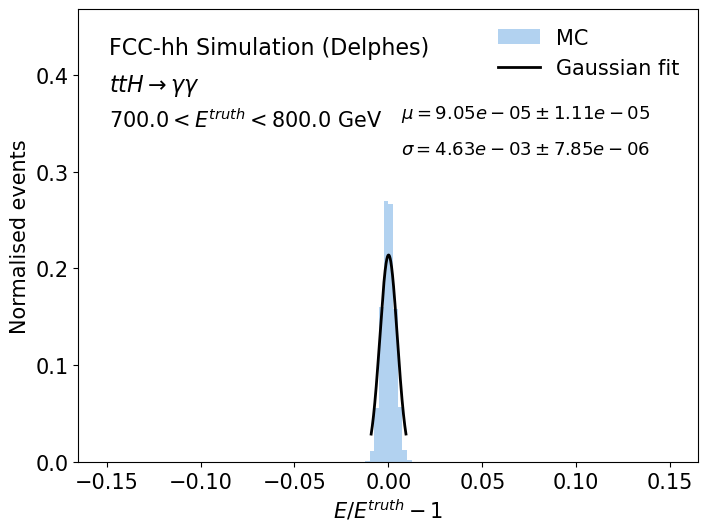

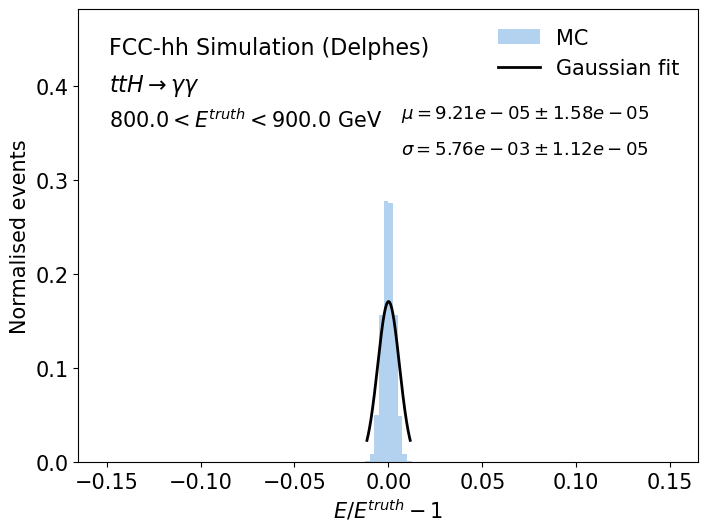

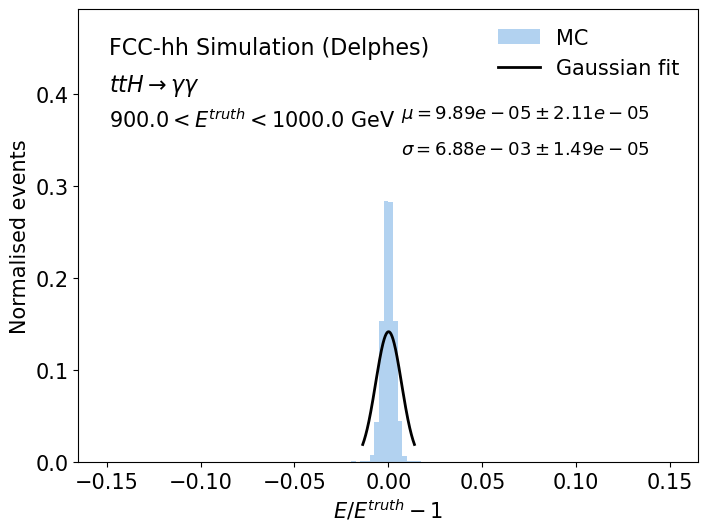

In [38]:
# loop over the energy bins
for ibin in range(1, len(ENERGY_BINS)) :
    
    # bin edges
    i_low = ENERGY_BINS[ibin-1]
    i_up = ENERGY_BINS[ibin]
    
    # select the bin
    df1 = dfss[dfss['energy_bin']==ibin]
    
    # plot eta - etatrue and phi - phitrue
    xmass = df1['E_y']/df1['true_E_y'] - np.ones(len(df1))
    
    mass = ROOT.RooRealVar("mass", "mass", -0.15, 0.15)
    rmass = ROOT.RooDataSet.from_numpy({"mass" : xmass.to_numpy()}, [mass])
    mmass = ROOT.RooRealVar("mu_mass", "mu_mass", 0., -1., 1.)
    smass = ROOT.RooRealVar("sigma_mass", "sigma_mass", 1., 0.001, 0.1)
    gmass = ROOT.RooGaussian("gaus_mass", "gaus_mass", mass, mmass, smass)
    gmass.fitTo(rmass)
    
    # save the std dev of these distributions
    y[ibin-1] = smass.getVal()
    yerr[ibin-1] = smass.getError()
    # make plots!
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )

    bin_values, bin_edges, _ = ax.hist(xmass,weights = np.ones(len(xmass))/len(xmass),
            bins=120, range=(-0.15,0.15), histtype='stepfilled', color=color_sequence[0], alpha=0.4,
           label='MC')
    bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
    
    # plot gaussian fit
    p0 = [1e-3,mmass.getVal(),smass.getVal()] #starting values for the fit
    p1, _ = curve_fit(fit_func,bin_centers,bin_values,p0,maxfev=10000)    
    x_axis = np.arange(mmass.getVal()-smass.getVal()*2,mmass.getVal()+smass.getVal()*2, 0.00001)
    x_bin = 0.5*(x_axis[1:]-x_axis[:-1])
    ax.plot(x_axis, norm.pdf(x_axis,mmass.getVal(),smass.getVal())*p1[0], color='k', lw=2, label='Gaussian fit')

    ax.legend(loc='upper right', frameon=False, fontsize=15)
    
    # save gaussian fit values
    ax.text(0.52, 0.76, r"$\mu={:.2e}\pm{:.2e}$".format(mmass.getVal(), mmass.getError()), transform=ax.transAxes, fontsize=13)
    ax.text(0.52, 0.68, r"$\sigma={:.2e}\pm{:.2e}$".format(smass.getVal(), smass.getError()), transform=ax.transAxes, fontsize=13)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<E^{truth}<$"+str(i_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = r"$E/E^{truth}-1$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
    plotname = "energy_in_energy_bin_"+str(ibin)
    #plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    #plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    #plt.show()

    del gmass
    del mmass
    del smass
    del rmass
    del mass

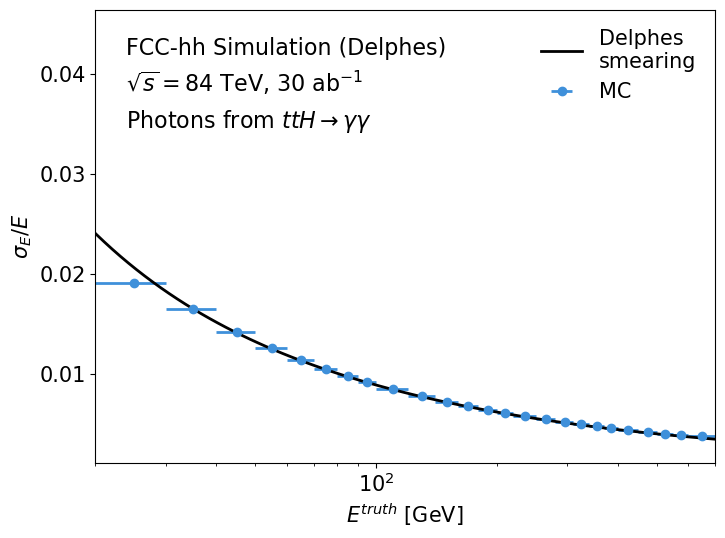

In [41]:
# plot of the resolution for E
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, color=color_sequence[0], marker='o', lw=2, ls='none', label="MC")
energy = np.logspace(1, 3, 100)
ax.plot(energy, sigma_e(energy)/energy, color='k', lw=2, label="Delphes\nsmearing")

ax.legend(loc='upper right', frameon=False, fontsize=15)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, r"Photons from $ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$E^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\sigma_{E}/E$')

ax.set_xscale("log")
ax.set_xlim(ENERGY_BINS[0], ENERGY_BINS[-4])

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.10)
    
plotname = "sigmae_overe_as_a_function_of_energy"
outdir = "/eos/user/e/elmazzeo/ttH@FCC-hh/presentations/"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

In [159]:
0.7124885963999704/60.

0.011874809939999507

In [163]:
np.sqrt(60**2*0.0015**2 + 60*0.082**2 + 0.31**2)

0.7124885963999704

In [132]:
def mass_resolution(e1, e2, se1, se2, m) :
    dm_de1 = 0.5*m/e1
    dm_de2 = 0.5*m/e2
    return np.sqrt((dm_de1*se1)**2+(dm_de2*se2)**2)

In [135]:
mass_resolution(60., 60., 0.7124885963999704, 0.7124885963999704, 125)

1.049594829234384

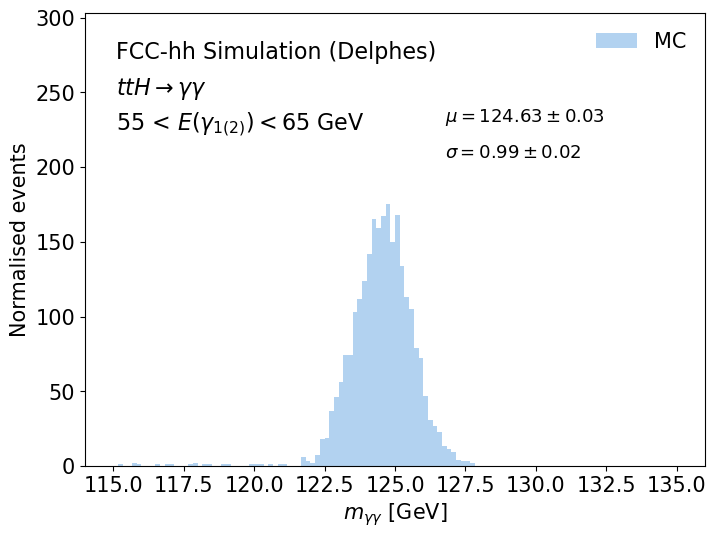

TH1.Print Name  = histofit, Entries= 2515, Total sum= 2438


In [162]:
# risoluzione in un bin in pT(H) per due fotoni a 60 GeV
fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
)

df1 = dfs.query("(E_y1>55) & (E_y2>55) & (E_y1<65) & (E_y2<65)")
#df1 = dfs.query("(m_yy>0)")
df1 = df1.query("(m_yy>110) & (m_yy<140)")

xmass = df1["m_yy"]

bin_values, bin_edges, _ = ax.hist(xmass,
    bins=120, range=(115,135), histtype='stepfilled', color=color_sequence[0], alpha=0.4,
    label='MC')
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

# plot IQR
iqr, iqr_err = interquartileEff(xmass)
iqr = iqr[0]
iqr_err = iqr_err[0]
param_values, param_errors = get_gaussian_fit(xmass)

# plot gaussian fit
#x_axis = np.arange(param_values[1]-param_values[2]*2,param_values[1]+param_values[2]*2, 0.02)
#ax.plot(x_axis, norm.pdf(x_axis,param_values[1],param_values[2])*param_values[0]*1.5, color='k', lw=2, label='Gaussian fit')

ax.legend(loc='upper right', frameon=False, fontsize=15)
    
# save gaussian fit values
ax.text(0.58, 0.76, r"$\mu={:.2f}\pm{:.2f}$".format(param_values[1],param_errors[1]), transform=ax.transAxes, fontsize=13)
ax.text(0.58, 0.68, r"$\sigma={:.2f}\pm{:.2f}$".format(iqr,iqr_err), transform=ax.transAxes, fontsize=13)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, r"55 < $E(\gamma_{1(2)})<65$ GeV", transform=ax.transAxes, fontsize=16)
xlabel = r"$m_{\gamma\gamma}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
plotname = "myy_pTH_bin_"+str(ibin)
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()


In [141]:
param_values

[306.09973503995366, 124.63331281511796, 0.9312853981059415]